-------------------------------------------------------------
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 4 : classifiez automatiquement des informations
-------------------------------------------------------------

## Partie 1 - Etape préalable

In [441]:
# Contrôle présence venv uv 
import sys
print(sys.executable)

/mnt/projects/ai_engineer_projects/P04/.venv/bin/python3


In [442]:
# Contrôle version python
sys.version

'3.11.15 (main, Mar 10 2026, 18:16:52) [Clang 21.1.4 ]'

In [443]:
# Contrôle présence des bibliothèques installées dans le venv uv
import importlib.metadata as md

packages = [
    "imbalanced-learn", "ipykernel", "jupyterlab",
    "matplotlib", "missingno", "numpy", "pandas", 
    "plotly", "psycopg2-binary", "pyarrow" , "scikit-learn",
    "scipy", "seaborn", "shap", "sqlalchemy", "statsmodels"
]

for p in packages:
    try:
        print(p, md.version(p))
    except:
        print(p, "missing")

imbalanced-learn 0.14.1
ipykernel 7.2.0
jupyterlab 4.5.6
matplotlib 3.10.8
missingno 0.5.2
numpy 2.4.3
pandas 3.0.1
plotly 6.6.0
psycopg2-binary 2.9.11
pyarrow 23.0.1
scikit-learn 1.8.0
scipy 1.17.1
seaborn 0.13.2
shap 0.51.0
sqlalchemy 2.0.48
statsmodels 0.14.6


## Partie 2 - Etape 1 : Effectuer une analyse exploratoire des fichiers de données

#### EDA du dataframe df_sirh avant jointure

In [444]:
# Chargement en dataframes pandas des 3 fichiers sources sirh, évaluation et sondage  
import pandas as pd

In [445]:
df_sirh = pd.read_csv("../data/raw/extrait_sirh.csv")

In [446]:
df_sirh.head(3)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0


In [447]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 191.1 KB


In [448]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sirh.rename(columns={
    "id_employee": "id_salarie",
    "nombre_heures_travailless": "nombre_heures_travaillees",
    "annee_experience_totale" : "nombre_total_annees_experience",
    "annees_dans_l_entreprise" : "nombre_total_annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel" : "nombre_total_annees_dans_le_poste_actuel"  
}, inplace=True)

In [449]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [450]:
# identification des colonnes numériques
int_cols_sirh = df_sirh.select_dtypes(include="int64").columns
print(int_cols_sirh)

Index(['id_salarie', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travaillees', 'nombre_total_annees_experience',
       'nombre_total_annees_dans_l_entreprise',
       'nombre_total_annees_dans_le_poste_actuel'],
      dtype='str')


In [451]:
# Vérification absence de decimales sur les valeurs au format int64
for col in int_cols_sirh:
    a_decimales = (df_sirh[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

id_salarie a décimales ? False
age a décimales ? False
revenu_mensuel a décimales ? False
nombre_experiences_precedentes a décimales ? False
nombre_heures_travaillees a décimales ? False
nombre_total_annees_experience a décimales ? False
nombre_total_annees_dans_l_entreprise a décimales ? False
nombre_total_annees_dans_le_poste_actuel a décimales ? False


In [452]:
# Identification des colonnes type chaînes de caractères
string_cols_sirh = df_sirh.select_dtypes(include="str").columns
print(string_cols_sirh)

Index(['genre', 'statut_marital', 'departement', 'poste'], dtype='str')


In [453]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
<ArrowStringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str
<ArrowStringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str


In [454]:
# Retirer les majuscules, espaces, accents et parenthèses
import unicodedata

df_sirh[string_cols_sirh] = df_sirh[string_cols_sirh].apply(
    lambda string_cols_sirh: string_cols_sirh.astype(str)
    .str.lower()
    .str.replace(r"[()]", "", regex=True)  
    .str.replace(" ", "_")
    .str.strip("_") 
    .map(lambda x: unicodedata.normalize("NFKD", x)
         .encode("ascii", errors="ignore")
         .decode("utf-8"))
)

In [455]:
# Réafficher les colonnes types chaînes de caractères mises en forme
for col in string_cols_sirh:
    print(df_sirh[col].unique()) 

<ArrowStringArray>
['f', 'm']
Length: 2, dtype: str
<ArrowStringArray>
['celibataire', 'mariee', 'divorcee']
Length: 3, dtype: str
<ArrowStringArray>
['commercial', 'consulting', 'ressources_humaines']
Length: 3, dtype: str
<ArrowStringArray>
[       'cadre_commercial',  'assistant_de_direction',
              'consultant',               'tech_lead',
                 'manager',          'senior_manager',
 'representant_commercial',     'directeur_technique',
     'ressources_humaines']
Length: 9, dtype: str


In [456]:
# Recherche de valeurs manquantes 
df_sirh.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

id_salarie                                  0
age                                         0
genre                                       0
revenu_mensuel                              0
statut_marital                              0
departement                                 0
poste                                       0
nombre_experiences_precedentes              0
nombre_heures_travaillees                   0
nombre_total_annees_experience              0
nombre_total_annees_dans_l_entreprise       0
nombre_total_annees_dans_le_poste_actuel    0
dtype: int64

In [457]:
# Contrôle présence de doublons sur la colonne id_salarie
df_sirh["id_salarie"].duplicated().any()

np.False_

In [458]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   id_salarie                                1470 non-null   int64
 1   age                                       1470 non-null   int64
 2   genre                                     1470 non-null   str  
 3   revenu_mensuel                            1470 non-null   int64
 4   statut_marital                            1470 non-null   str  
 5   departement                               1470 non-null   str  
 6   poste                                     1470 non-null   str  
 7   nombre_experiences_precedentes            1470 non-null   int64
 8   nombre_heures_travaillees                 1470 non-null   int64
 9   nombre_total_annees_experience            1470 non-null   int64
 10  nombre_total_annees_dans_l_entreprise     1470 non-null   int64
 11  no

In [459]:
# Statistiques descriptives du dataframe df_sirh
df_sirh.describe().T

,count,mean,std,min,25%,50%,75%,max
id_salarie,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travaillees,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0


### premiere analyse des statistiques descriptives
* anomalies du nombre d'heures travaillées car tous les salariés sont à 80h soit plus de deux fois 35h => cette colonne est peu informative et pourra donc être ignorée
*  la moyenne d'âge des salariés est de 36 ans
*  la distribution des âges des salariés est équilibrée car moyenne = médiane
*  le nombre d'années moyen passées dans l'entreprise est autour de **7 ans**

In [460]:
# suppression de la colonne nombre d'heures travaillées
df_sirh.drop(columns=["nombre_heures_travaillees"], inplace=True)

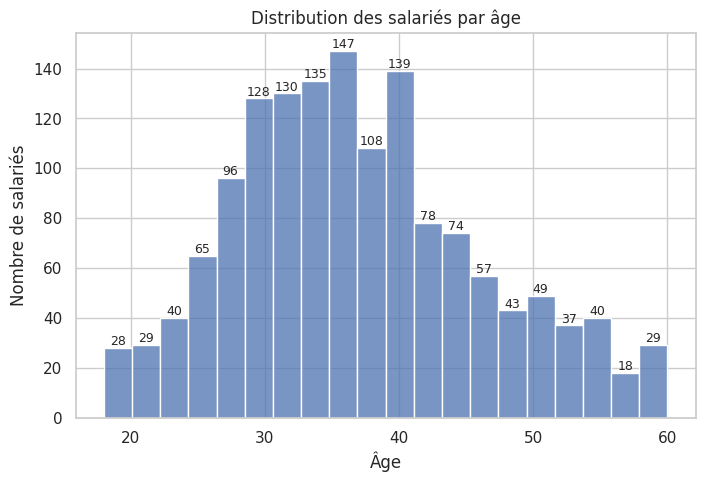

In [461]:
# distribution des âges des salariés

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["age"], bins=20)

plt.title("Distribution des salariés par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

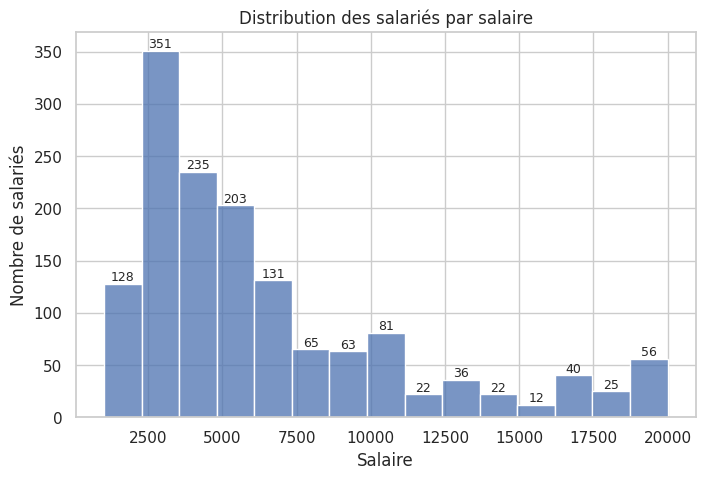

In [462]:
# distribution des revenus mensuels
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["revenu_mensuel"], bins=15)

plt.title("Distribution des salariés par salaire")
plt.xlabel("Salaire")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

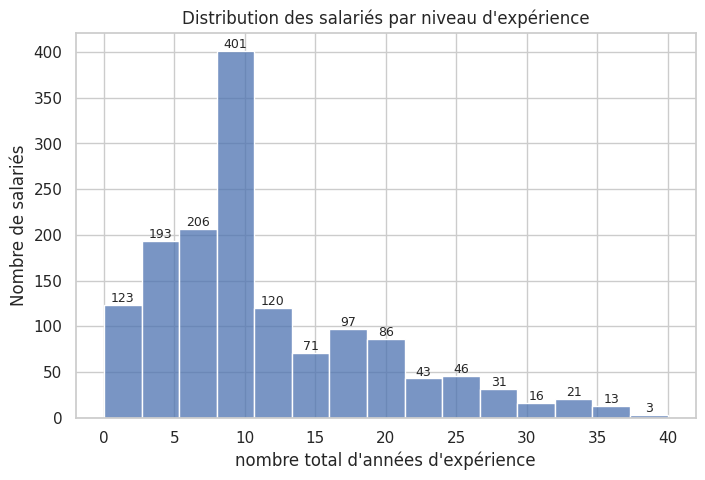

In [463]:
#  Distribution du nombre total d'annees d'experience 
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_experience"], bins=15)

plt.title("Distribution des salariés par niveau d'expérience")
plt.xlabel("nombre total d'années d'expérience")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

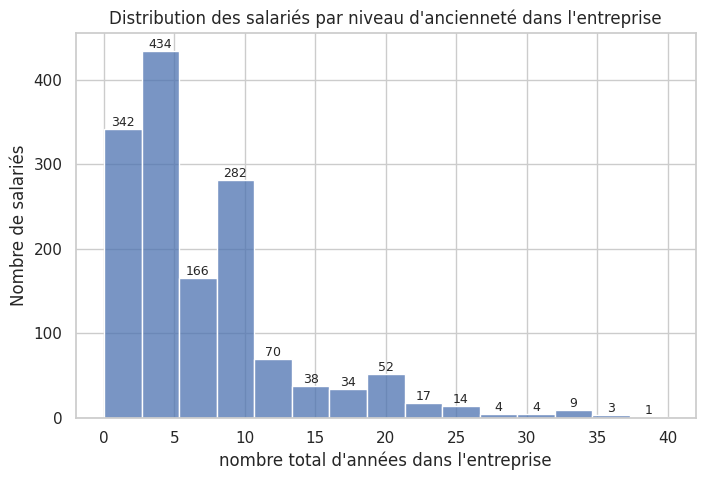

In [464]:
# Distribution du niveau d'ancienneté dans l'entreprise
plt.figure(figsize=(8,5))

ax = sns.histplot(df_sirh["nombre_total_annees_dans_l_entreprise"], bins=15)

plt.title("Distribution des salariés par niveau d'ancienneté dans l'entreprise")
plt.xlabel("nombre total d'années dans l'entreprise")
plt.ylabel("Nombre de salariés")

# ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.show()

### observations
* le salaire médian de 4 900 € représente le cœur de la population salariale
* la majorité des salariés quittent avant 10 ans
* peu de salariés atteignent donc les niveaux d’ancienneté élevés
* cela peut limiter la progression salariale globale et **potentiellement influencer le turnover**

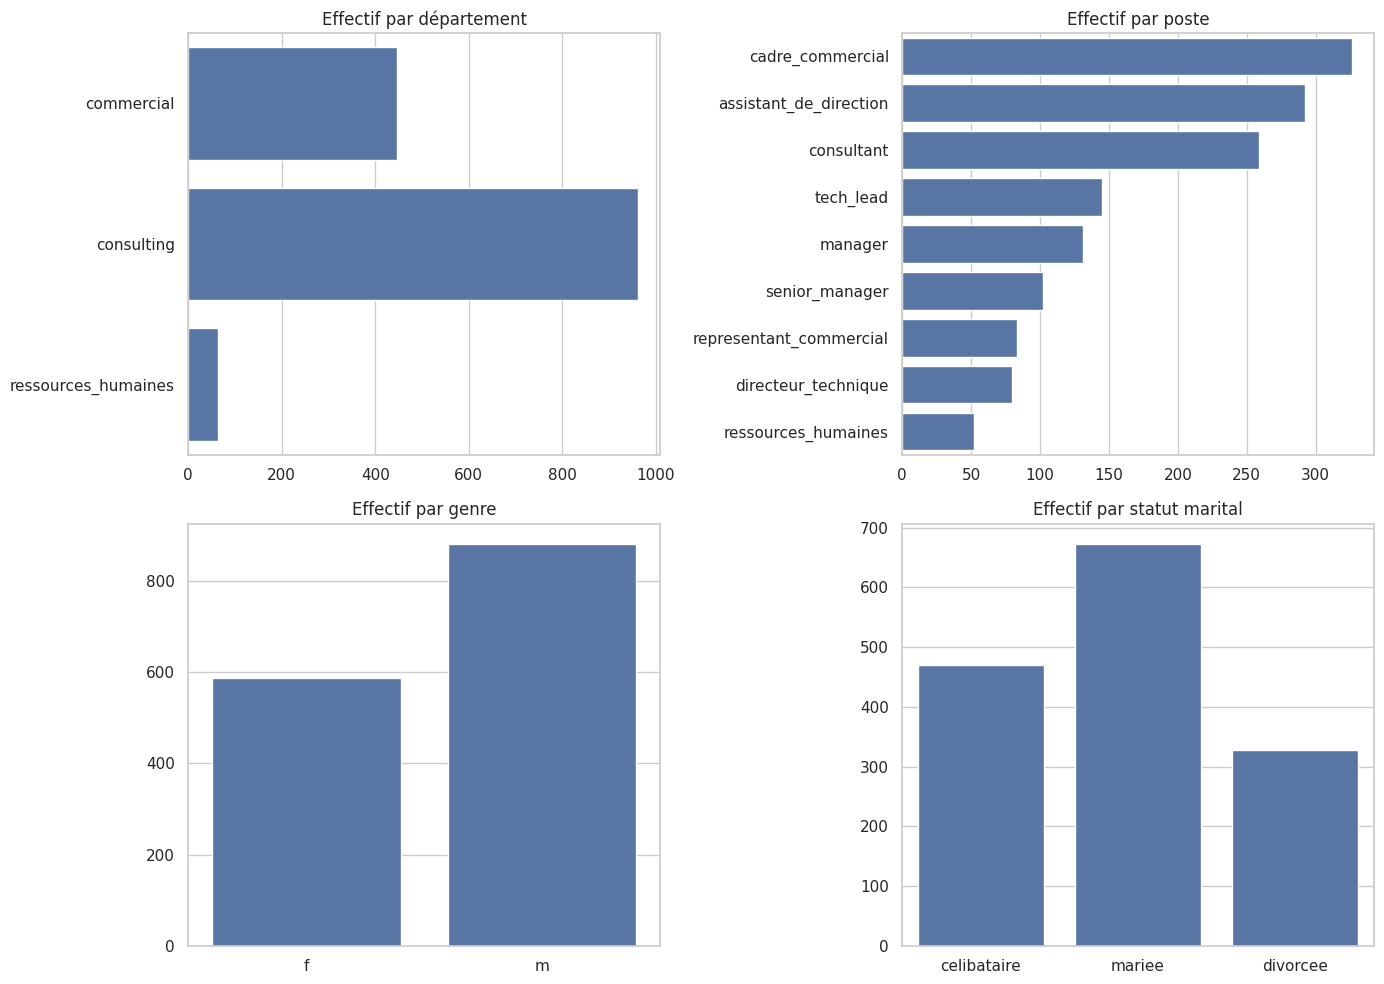

In [465]:
# Distribution par département, poste, genre et statut marital

import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    ("departement", "Effectif par département", "y"),
    ("poste", "Effectif par poste", "y"),
    ("genre", "Effectif par genre", "x"),
    ("statut_marital", "Effectif par statut marital", "x")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, title, orient) in enumerate(cols):
    
    if orient == "y":
        sns.countplot(y=df_sirh[col], ax=axes[i])
    else:
        sns.countplot(x=df_sirh[col], ax=axes[i])
    
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### observations
* les postes de cadre commercial, assistant de direction et de consultant sont les plus représentés
* il n'y a pas de déséquilibre profond entre hommes et femmes bien que ces dernières soient à 25% moins représentées que les hommes

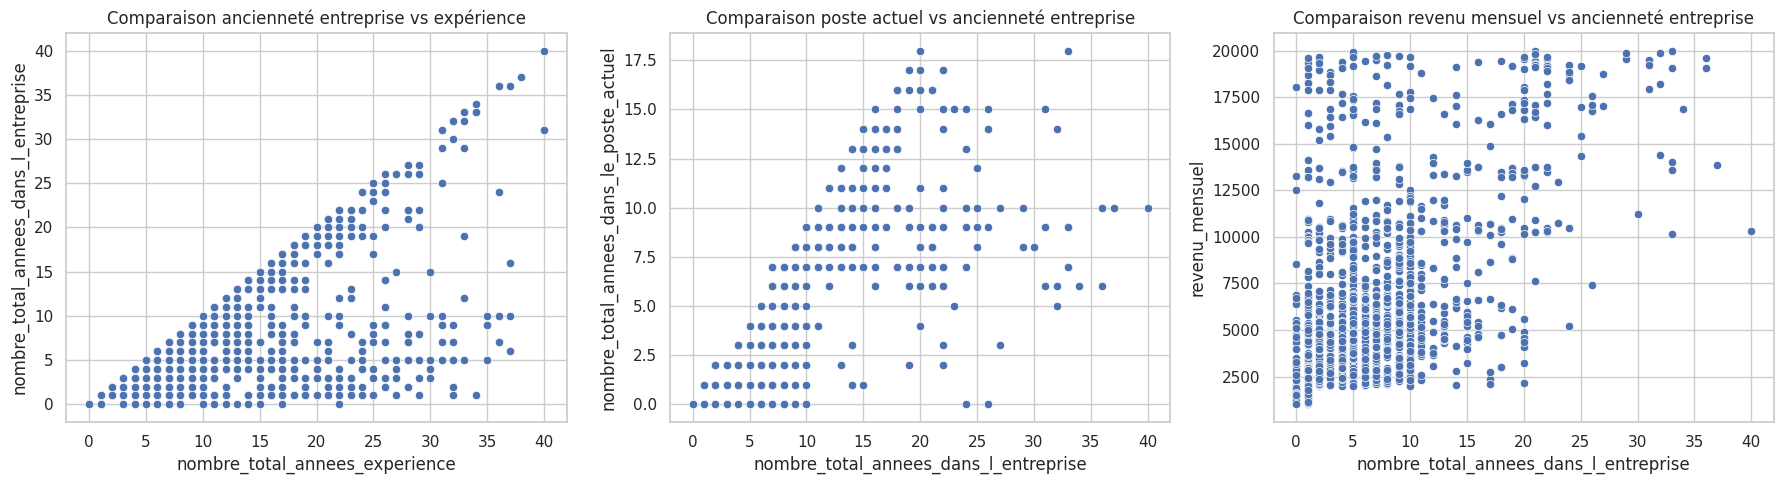

In [466]:
# Recherche de premieres corrélations
import matplotlib.pyplot as plt
import seaborn as sns

plots = [
    (
        "nombre_total_annees_experience",
        "nombre_total_annees_dans_l_entreprise",
        "Comparaison ancienneté entreprise vs expérience"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "nombre_total_annees_dans_le_poste_actuel",
        "Comparaison poste actuel vs ancienneté entreprise"
    ),
    (
        "nombre_total_annees_dans_l_entreprise",
        "revenu_mensuel",
        "Comparaison revenu mensuel vs ancienneté entreprise"
    )
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x, y, title) in enumerate(plots):
    sns.scatterplot(
        data=df_sirh,
        x=x,
        y=y,
        ax=axes[i]
    )
    axes[i].set_title(title)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

plt.tight_layout()
plt.show()

### observations
* les salariés arrivent dans l'entreprise avec de l'entreprise déjà acquise ailleurs
* les salariés dans l'entreprise changent régulièrement de poste ce qui peut signifier soit **promotions** soit **restructurations fréquentes**

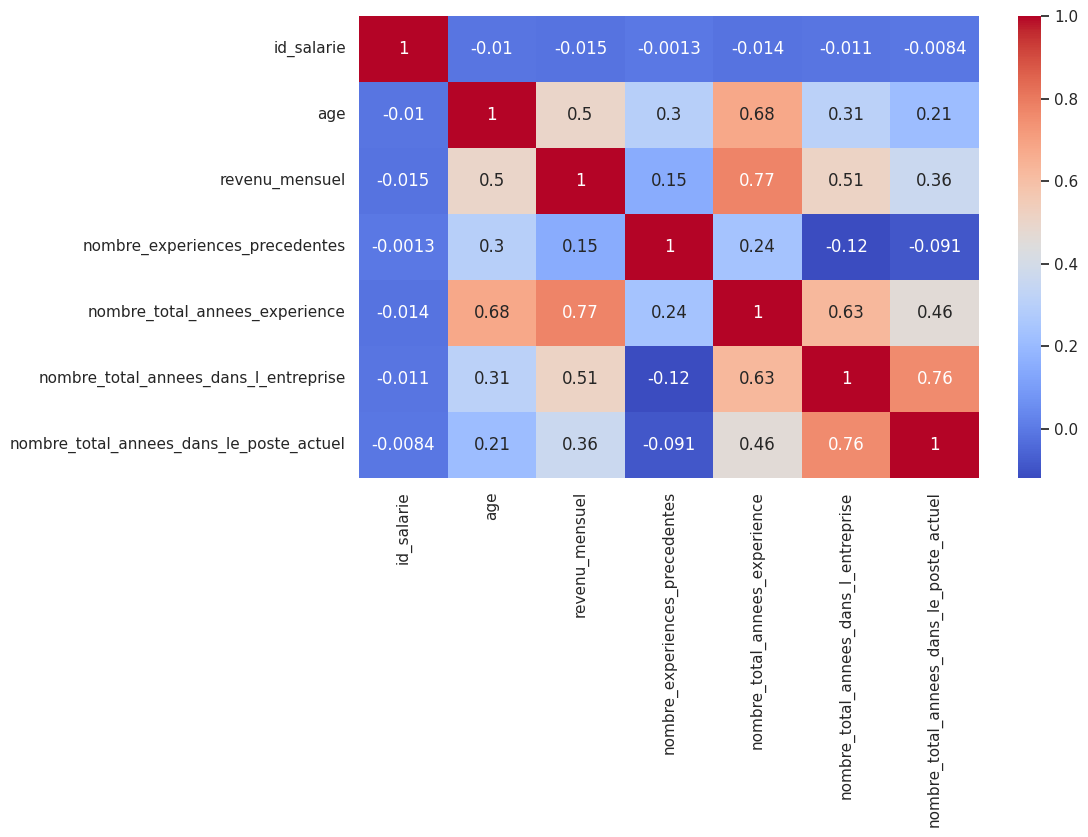

In [467]:
# Matrice globale des corrélations de df_sirh
plt.figure(figsize=(10,6))
sns.heatmap(df_sirh.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

### observartions de la heatmap
Les variables suivantes sont fortement corrélées entre elles
* l'âge augmente avec l'expérience
* l'expérience augmente avec le salaire 
* l'ancienneté augmente sans nécessairement changer de poste (soit f**aible mobilité interne pouvant epxliquer les départs** soit **évolution lente**)

Ces variables corrélées amènent de la **multicolinéarité ** qui peut rendre les **poids instables** et **l'interprétation biaisée** dans une modélisaiton de machine learning. Il faudra donc:
* soit garder l'âge
* soit garder l'expérience
* ou créer une feature “ratio salaire / expérience”

#### EDA du dataframe df_eval avant jointure

In [468]:
df_eval = pd.read_csv("../data/raw/extrait_eval.csv")

In [469]:
df_eval.head(3)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %


In [470]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [471]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_eval.rename(columns={
    "satisfaction_employee_environnement": "satisfaction_salarie_environnement",
    "satisfaction_employee_nature_travail": "satisfaction_salarie_nature_travail",
    "satisfaction_employee_equipe": "satisfaction_salarie_equipe",
    "satisfaction_employee_equilibre_pro_perso" : "satisfaction_salarie_equilibre_pro_perso",
    "eval_number" : "numero_d_evaluation",
    "heure_supplementaires" : "heures_supplementaires",
    "augementation_salaire_precedente" : "precedent_pourcentage_d_augmentation"  
}, inplace=True)

In [472]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   str  
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 132.9 KB


In [473]:
int_cols_eval = df_eval.select_dtypes(include="int64").columns
print(int_cols_eval)

Index(['satisfaction_salarie_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail',
       'satisfaction_salarie_equipe',
       'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle'],
      dtype='str')


In [474]:
for col in int_cols_eval:
    a_decimales = (df_eval[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

satisfaction_salarie_environnement a décimales ? False
note_evaluation_precedente a décimales ? False
niveau_hierarchique_poste a décimales ? False
satisfaction_salarie_nature_travail a décimales ? False
satisfaction_salarie_equipe a décimales ? False
satisfaction_salarie_equilibre_pro_perso a décimales ? False
note_evaluation_actuelle a décimales ? False


In [475]:
# Identification des colonnes type chaînes de caractères
string_cols_eval = df_eval.select_dtypes(include="str").columns
print(string_cols_eval)

Index(['numero_d_evaluation', 'heures_supplementaires',
       'precedent_pourcentage_d_augmentation'],
      dtype='str')


In [476]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_eval:
    print(df_eval[col].unique()) 

<ArrowStringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str
<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


In [477]:
df_sirh["id_salarie"].min(), df_sirh["id_salarie"].max()

(np.int64(1), np.int64(2068))

In [478]:
# Transformer les colonnes au format int64 
import re

df_eval["numero_d_evaluation"] = df_eval["numero_d_evaluation"].apply(
    lambda x: int(re.sub(r"\D", "", str(x)))
)

df_eval["heures_supplementaires"] = df_eval["heures_supplementaires"].apply(
    lambda x: str(x).strip().lower()
)

df_eval["precedent_pourcentage_d_augmentation"] = df_eval["precedent_pourcentage_d_augmentation"].apply(
    lambda x: int(re.sub(r"[^\d]", "", str(x)))
)

In [479]:
for col in string_cols_eval:
    print(df_eval[col].unique()) 

[   1    2    4 ... 2064 2065 2068]
<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
[11 23 15 12 13 20 22 21 17 14 16 18 19 24 25]


In [480]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [481]:
# Recherche de valeurs manquantes 
df_eval.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

satisfaction_salarie_environnement          0
note_evaluation_precedente                  0
niveau_hierarchique_poste                   0
satisfaction_salarie_nature_travail         0
satisfaction_salarie_equipe                 0
satisfaction_salarie_equilibre_pro_perso    0
numero_d_evaluation                         0
note_evaluation_actuelle                    0
heures_supplementaires                      0
precedent_pourcentage_d_augmentation        0
dtype: int64

In [482]:
# Contrôle présence de doublons sur la colonne numero_d_evaluation
df_eval["numero_d_evaluation"].duplicated().any()

np.False_

In [483]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   satisfaction_salarie_environnement        1470 non-null   int64
 1   note_evaluation_precedente                1470 non-null   int64
 2   niveau_hierarchique_poste                 1470 non-null   int64
 3   satisfaction_salarie_nature_travail       1470 non-null   int64
 4   satisfaction_salarie_equipe               1470 non-null   int64
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64
 6   numero_d_evaluation                       1470 non-null   int64
 7   note_evaluation_actuelle                  1470 non-null   int64
 8   heures_supplementaires                    1470 non-null   str  
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64
dtypes: int64(9), str(1)
memory usage: 119.3 KB


In [484]:
# Statistiques descriptives du dataframe df_eval
num_cols_eval = df_eval.select_dtypes(include="int64").columns
cat_cols_eval = df_eval.select_dtypes(include="str").columns
df_eval[num_cols_eval].describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
satisfaction_salarie_nature_travail,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equipe,1470.0,2.712245,1.081209,1.0,2.00,3.0,4.00,4.0
satisfaction_salarie_equilibre_pro_perso,1470.0,2.761224,0.706476,1.0,2.00,3.0,3.00,4.0
numero_d_evaluation,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.0,3.00,3.0,3.00,4.0
precedent_pourcentage_d_augmentation,1470.0,15.209524,3.659938,11.0,12.00,14.0,18.00,25.0


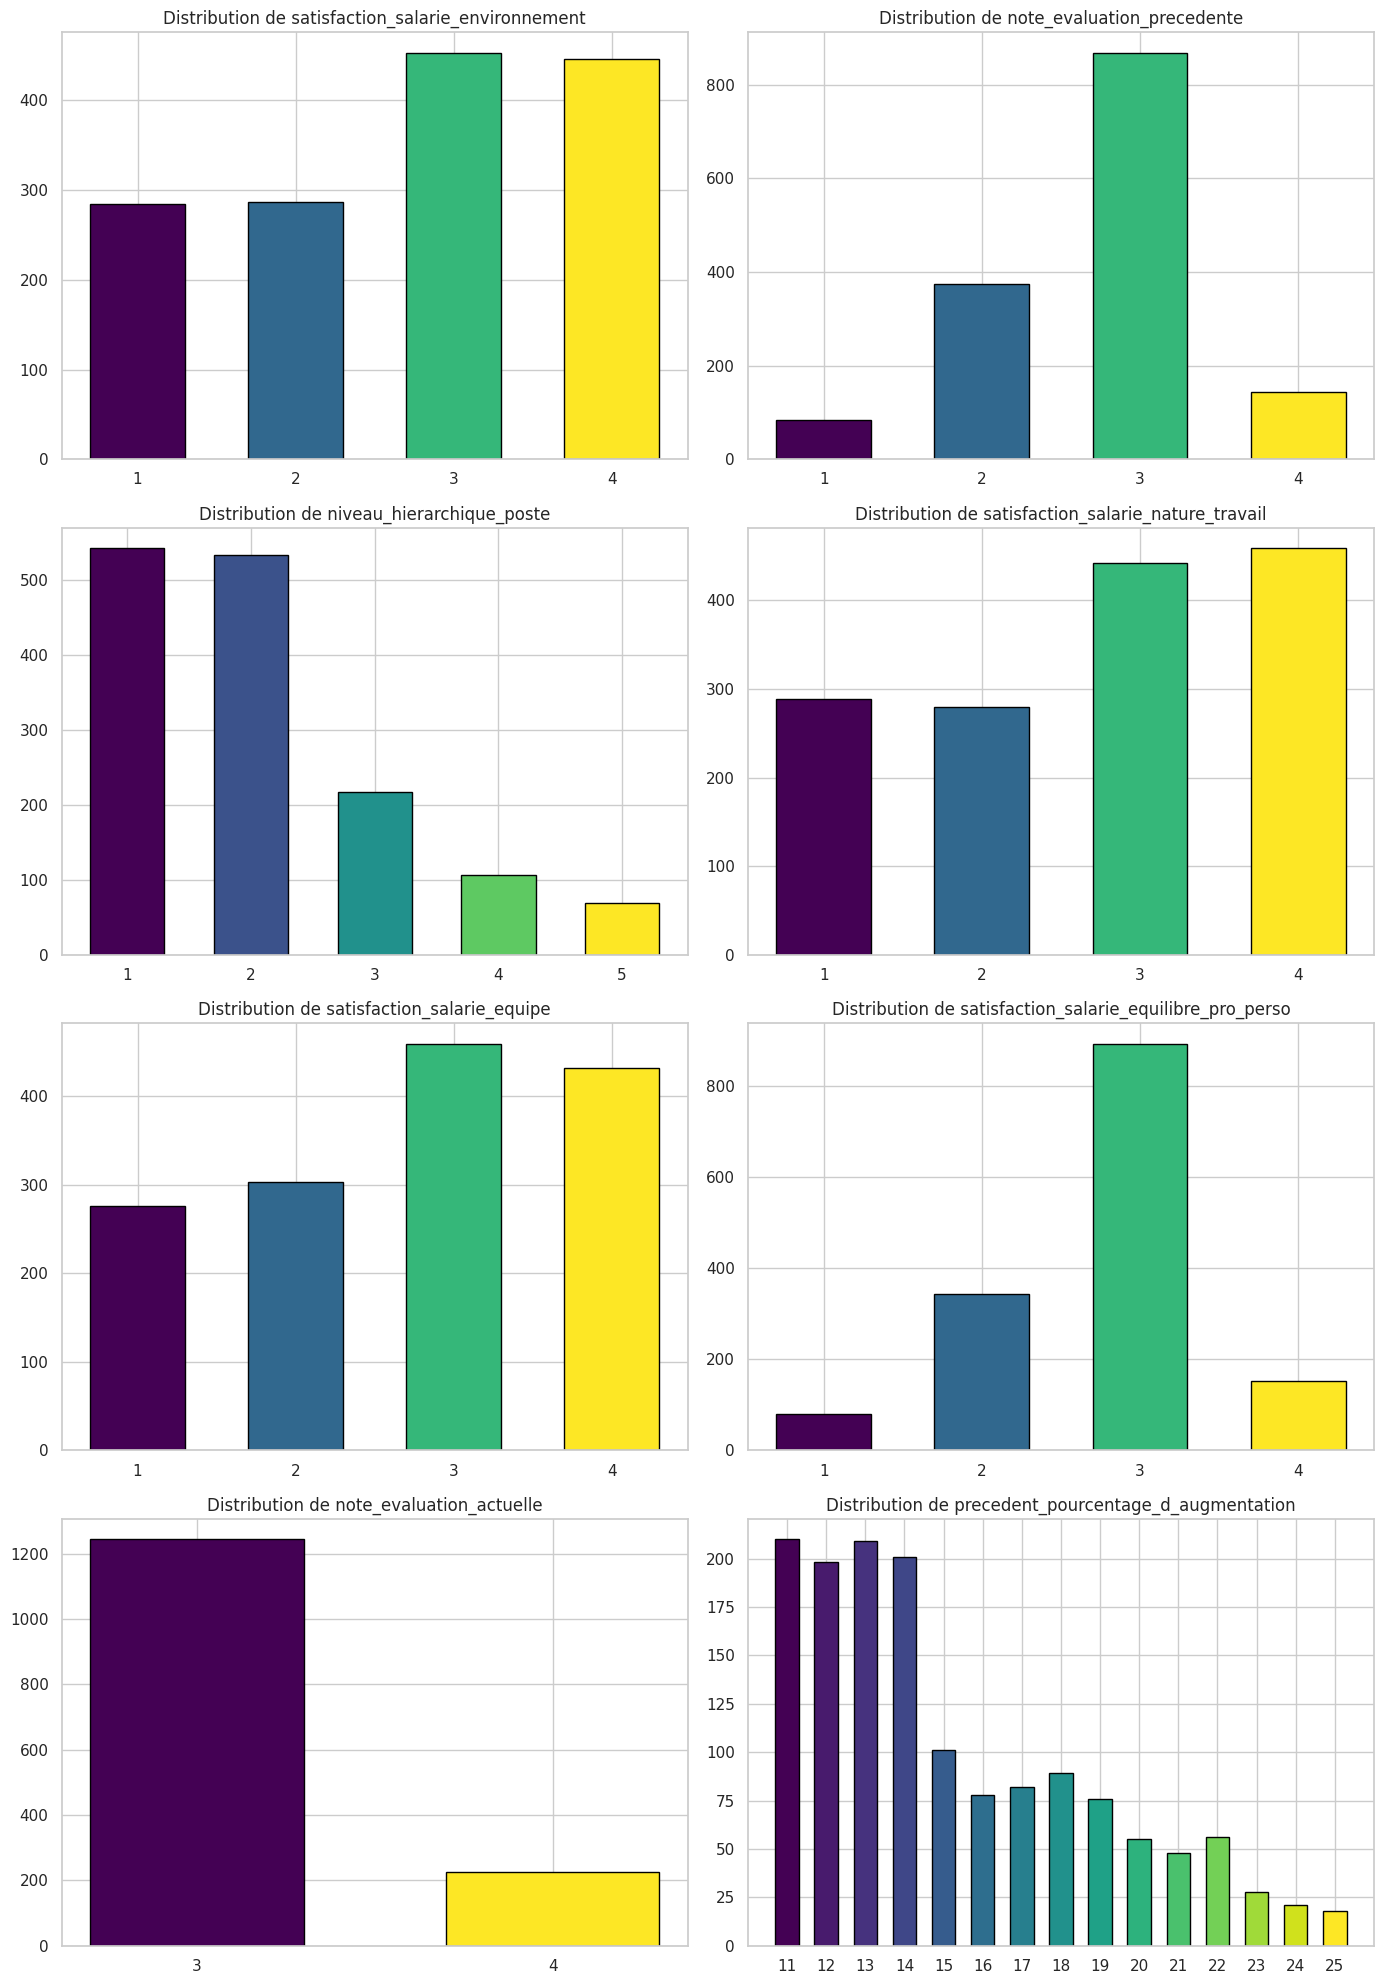

In [485]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

hierarchical_cols = ["niveau_hierarchique_poste"]
percent_cols = ["precedent_pourcentage_d_augmentation"]
exclude_cols = ["numero_d_evaluation"] 

# on retire la colonne du calcul
cols_to_plot = [col for col in num_cols_eval if col not in exclude_cols]

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.ravel()

cmap = plt.cm.viridis

for i, col in enumerate(cols_to_plot):

    # cas niveau hiérarchique
    if col in hierarchical_cols:
        levels = sorted(df_eval[col].unique())

    # cas pourcentage augmentation
    elif col in percent_cols:
        levels = sorted(df_eval[col].unique())
        axes[i].set_xlim(min(levels) - 1, max(levels) + 1)

    # autres variables numériques
    else:
        levels = sorted(df_eval[col].unique())

    # normalisation couleurs
    norm = mcolors.Normalize(vmin=min(levels), vmax=max(levels))

    counts = df_eval[col].value_counts().reindex(levels, fill_value=0)

    colors = [cmap(norm(x)) for x in counts.index]

    axes[i].bar(
        counts.index,
        counts.values,
        width=0.6,
        edgecolor="black",
        color=colors
    )

    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xticks(levels)

# supprimer axes inutilisés
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

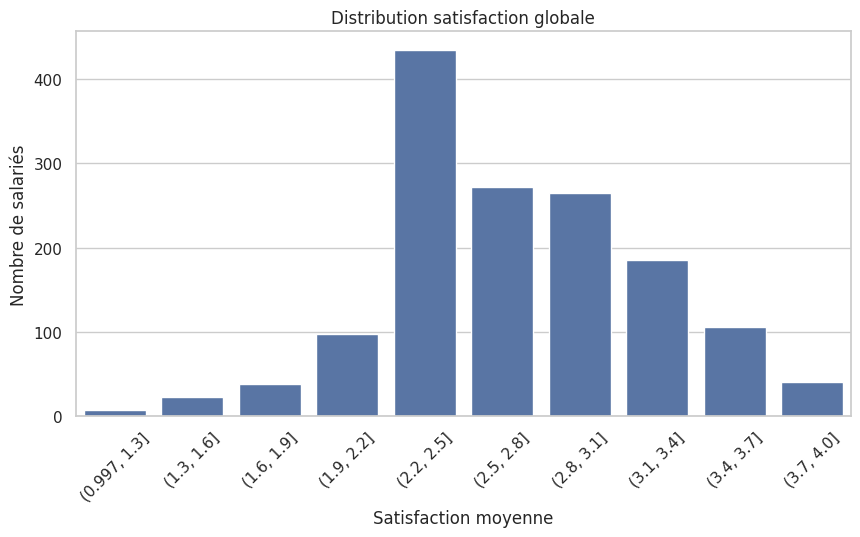

In [486]:

# création de la satisfaction moyenne
satisfaction_cols = [
    "satisfaction_salarie_environnement",
    "satisfaction_salarie_nature_travail",
    "satisfaction_salarie_equipe",
    "satisfaction_salarie_equilibre_pro_perso"
]

df_eval["satisfaction_moyenne"] = df_eval[satisfaction_cols].mean(axis=1)

# création des bins
df_eval["satisfaction_bin"] = pd.cut(
    df_eval["satisfaction_moyenne"],
    bins=10
)

# comptage par bin
bar_data = df_eval["satisfaction_bin"].value_counts().sort_index()

# barplot
plt.figure(figsize=(10,5))
sns.barplot(x=bar_data.index.astype(str), y=bar_data.values)

plt.xticks(rotation=45)
plt.title("Distribution satisfaction globale")
plt.xlabel("Satisfaction moyenne")
plt.ylabel("Nombre de salariés")

plt.show()

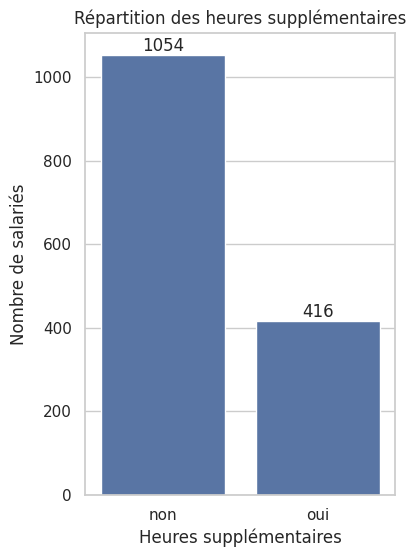

In [487]:
# distribution des heures supplémentaires

plt.figure(figsize=(4,6))

ax = sns.countplot(
    data=df_eval,
    x="heures_supplementaires",
    order=["non", "oui"] 
)

# titres
plt.title("Répartition des heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Nombre de salariés")

# ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container)

plt.show()

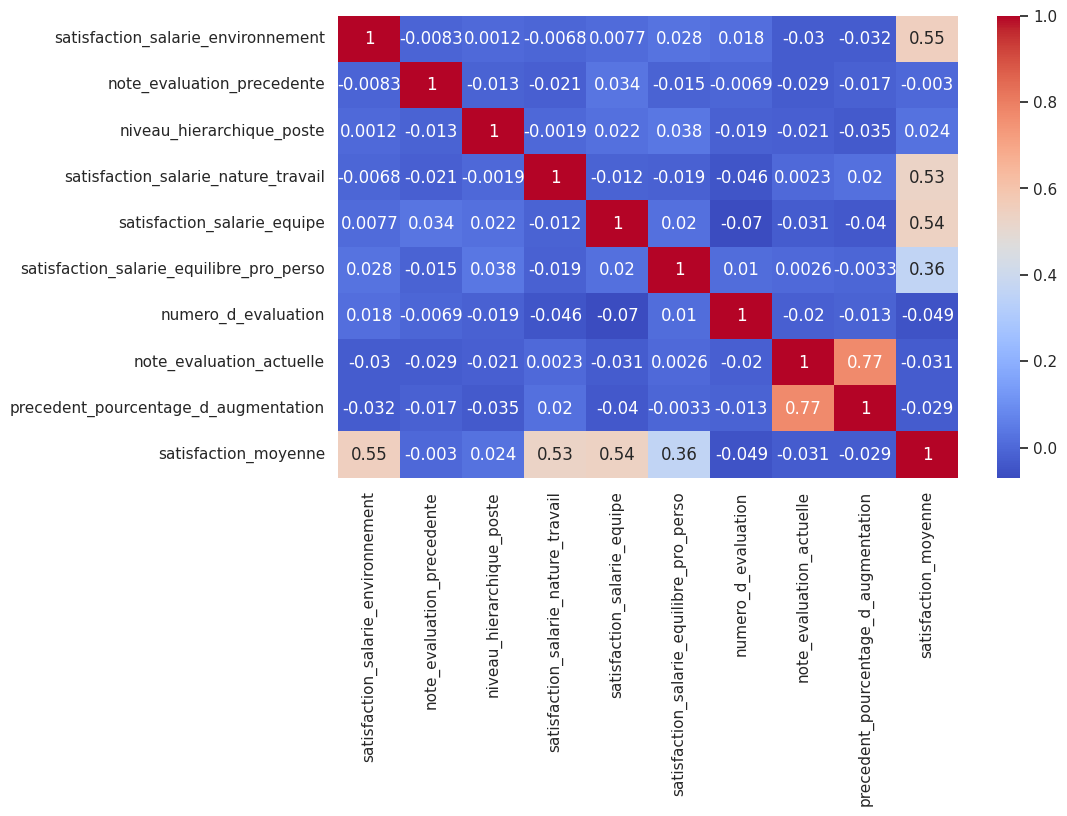

In [488]:
# matrice globale des corrélations de df_eval
plt.figure(figsize=(10,6))
sns.heatmap(df_eval.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

#### observations
* satisfaction globale moyenne mais pas excellente
* peu de différenciation individuelle sur l'augmentation salariale
* perception de l'environnement de travail globalement bonne mais pas homogène (400 personnes note 3 et 400 personnes note 4) ce qui peut cacher des différences dans les différents départements de travail
* le système de notation d'évaluation actuelle est peu discriminant par près de 80%  des salariés ont leur performance notée à 3. Or 400 salariés evaluent la satisfaction globale à 2 ce qui montre que les salariés évaluent moins bien leur bien-être (pouvant causer des départs) que leur performance ce qui est synonyme de stress global.
* 30% de l'effectif effectue des heures supplémentaires ce qui peut être source de stress
* plus la note d’évaluation est élevée, plus le pourcentage d’augmentation est élevé
* la note d’évaluation précédente n’a pas de corrélation linéaire simple avec la note actuelle (un salarié bien noté avant n’est pas forcément bien noté maintenant (et inversement)), ce qui peut suggérer que les signaux de départ sont plutôt dans le contexte actuel que dans l’historique


In [489]:
df_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   satisfaction_salarie_environnement        1470 non-null   int64   
 1   note_evaluation_precedente                1470 non-null   int64   
 2   niveau_hierarchique_poste                 1470 non-null   int64   
 3   satisfaction_salarie_nature_travail       1470 non-null   int64   
 4   satisfaction_salarie_equipe               1470 non-null   int64   
 5   satisfaction_salarie_equilibre_pro_perso  1470 non-null   int64   
 6   numero_d_evaluation                       1470 non-null   int64   
 7   note_evaluation_actuelle                  1470 non-null   int64   
 8   heures_supplementaires                    1470 non-null   str     
 9   precedent_pourcentage_d_augmentation      1470 non-null   int64   
 10  satisfaction_moyenne               

#### EDA du dataframe df_sondage avant jointure

In [490]:
df_sondage = pd.read_csv("../data/raw/extrait_sondage.csv")

In [491]:
df_sondage.head(3)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0


In [492]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [493]:
# Renommer certaines colonnes sans dupliquer le dataframe 
df_sondage.rename(columns={
    "nb_formations_suivies" : "nombre_de_formations_suivies",
    "nombre_employee_sous_responsabilite" : "nombre_de_salaries_sous_sa_responsabilite",
    "annees_depuis_la_derniere_promotion" : "nombre_d_annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel" : "nombre_d_annees_sous_le_responsable_actuel"
}, inplace=True)

In [494]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [495]:
int_cols_sondage = df_sondage.select_dtypes(include="int64").columns
print(int_cols_sondage)

Index(['nombre_participation_pee', 'nombre_de_formations_suivies',
       'nombre_de_salaries_sous_sa_responsabilite', 'code_sondage',
       'distance_domicile_travail', 'niveau_education',
       'nombre_d_annees_depuis_la_derniere_promotion',
       'nombre_d_annees_sous_le_responsable_actuel'],
      dtype='str')


In [496]:
for col in int_cols_sondage:
    a_decimales = (df_sondage[col] % 1 != 0).any()
    print(col, "a décimales ?" , a_decimales)

nombre_participation_pee a décimales ? False
nombre_de_formations_suivies a décimales ? False
nombre_de_salaries_sous_sa_responsabilite a décimales ? False
code_sondage a décimales ? False
distance_domicile_travail a décimales ? False
niveau_education a décimales ? False
nombre_d_annees_depuis_la_derniere_promotion a décimales ? False
nombre_d_annees_sous_le_responsable_actuel a décimales ? False


In [497]:
# Identification des colonnes type chaînes de caractères
string_cols_sondage = df_sondage.select_dtypes(include="str").columns
print(string_cols_sondage)

Index(['a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants',
       'frequence_deplacement'],
      dtype='str')


In [498]:
# Recherche des différentes instances de chacune des colonnes type chaînes de caractères
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['Oui', 'Non']
Length: 2, dtype: str
<ArrowStringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str
<ArrowStringArray>
['Y']
Length: 1, dtype: str
<ArrowStringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str


In [499]:
# Recherche de valeurs manquantes 
df_sondage.apply(lambda col: col.isna().sum()).sort_values(ascending=False)

a_quitte_l_entreprise                           0
nombre_participation_pee                        0
nombre_de_formations_suivies                    0
nombre_de_salaries_sous_sa_responsabilite       0
code_sondage                                    0
distance_domicile_travail                       0
niveau_education                                0
domaine_etude                                   0
ayant_enfants                                   0
frequence_deplacement                           0
nombre_d_annees_depuis_la_derniere_promotion    0
nombre_d_annees_sous_le_responsable_actuel      0
dtype: int64

In [500]:
# Retirer les majuscules, espaces, & et remplacer Y par oui
df_sondage[string_cols_sondage] = df_sondage[string_cols_sondage].apply(
    lambda col: col.astype(str)
    .str.strip()
    .str.lower()
    .str.replace("&", "et", regex=False)
    .str.replace(" ", "_", regex=False)
    .apply(lambda x: "oui" if x == "y" else x)
)

In [501]:
for col in string_cols_sondage:
    print(df_sondage[col].unique()) 

<ArrowStringArray>
['oui', 'non']
Length: 2, dtype: str
<ArrowStringArray>
[         'infra_et_cloud',                   'autre',
 'transformation_digitale',               'marketing',
         'entrepreunariat',     'ressources_humaines']
Length: 6, dtype: str
<ArrowStringArray>
['oui']
Length: 1, dtype: str
<ArrowStringArray>
['occasionnel', 'frequent', 'aucun']
Length: 3, dtype: str


In [502]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   nombre_de_salaries_sous_sa_responsabilite     1470 non-null   int64
 4   code_sondage                                  1470 non-null   int64
 5   distance_domicile_travail                     1470 non-null   int64
 6   niveau_education                              1470 non-null   int64
 7   domaine_etude                                 1470 non-null   str  
 8   ayant_enfants                                 1470 non-null   str  
 9   frequence_deplacement                         1470 non-null   str  
 10  nombre_d_annees_depuis_

In [503]:
df_sondage["code_sondage"].min(), df_sondage["code_sondage"].max()

(np.int64(1), np.int64(2068))

In [504]:
# Contrôle présence de doublons sur la colonne code_sondage
df_sondage["code_sondage"].duplicated().any()

np.False_

In [505]:
# statistiques descriptiques du dataframe df_sondage
df_sondage.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nombre_de_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_de_salaries_sous_sa_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
code_sondage,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
nombre_d_annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
nombre_d_annees_sous_le_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0


Le nombre de salaries sous sa responsaiblité est toujours égal à 1 donc pas de variaiblité dans les données , la colonne pourra être retirée du dataframe.

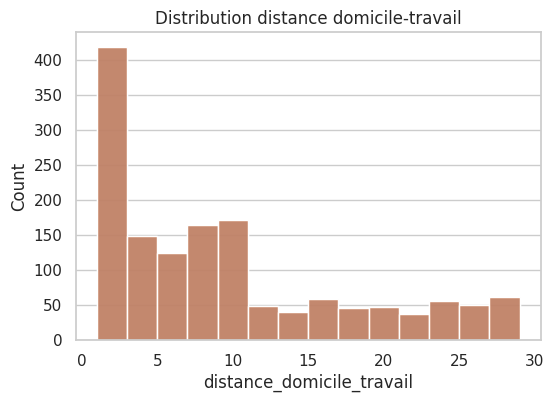

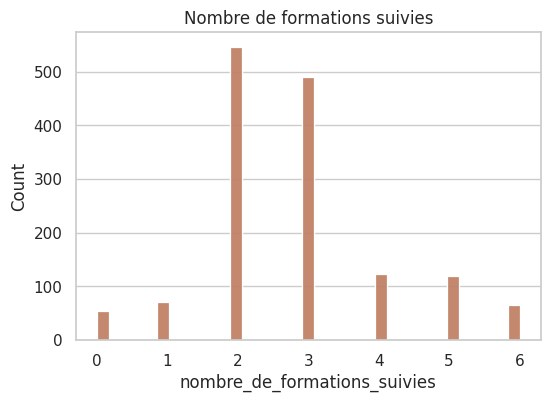

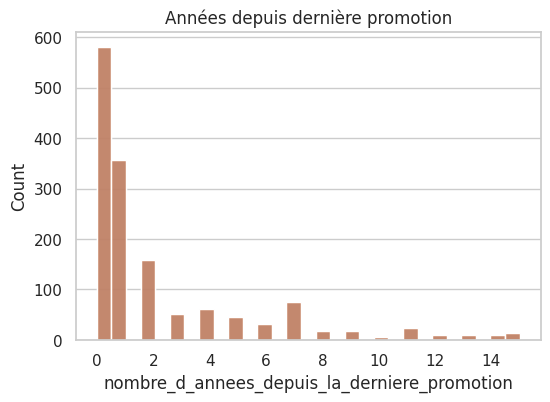

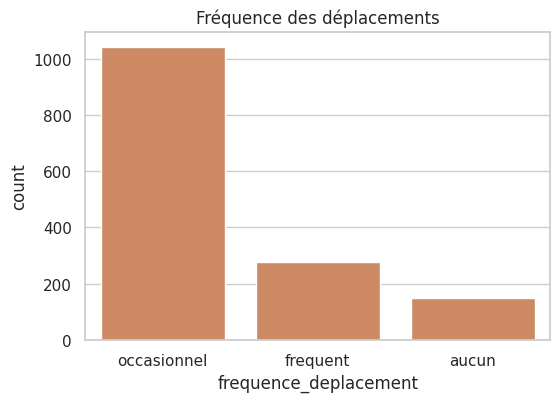

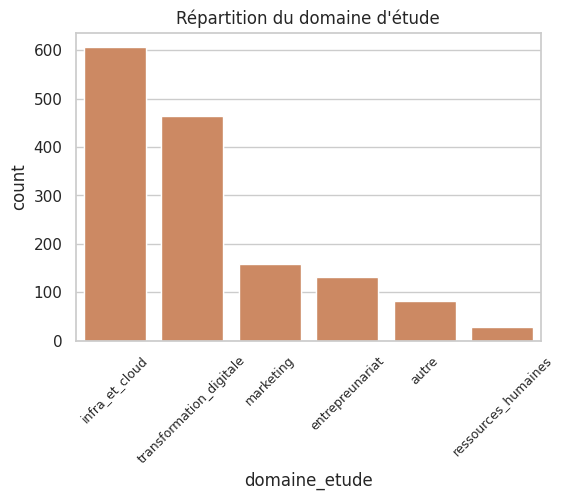

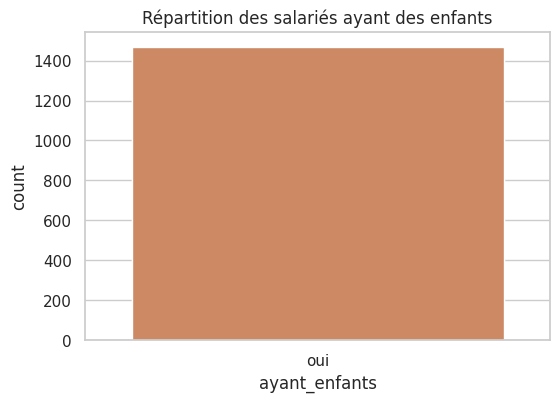

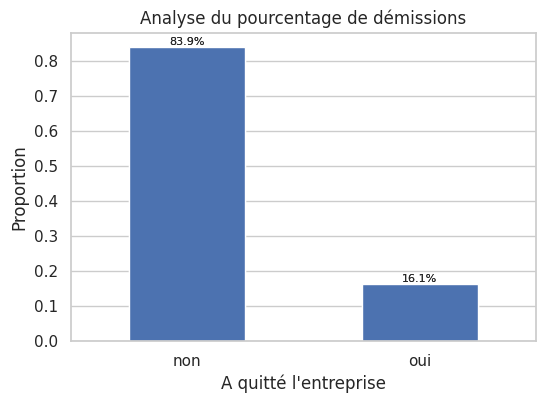

In [506]:
# Visualisations univariées

sns.set_style("whitegrid", {'axes.grid.axis': 'y'})
plt.rcParams["figure.figsize"] = (6, 4)

# Distance domicile-travail
sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax = sns.histplot(df_sondage["distance_domicile_travail"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Distribution distance domicile-travail")
plt.show()

# Formations suivies
sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax = sns.histplot(df_sondage["nombre_de_formations_suivies"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Nombre de formations suivies")
plt.show()

# Années depuis dernière promotion
sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax = sns.histplot(df_sondage["nombre_d_annees_depuis_la_derniere_promotion"], kde=False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Années depuis dernière promotion")
plt.show()

# Fréquence des déplacements
sns.countplot(data=df_sondage, x="frequence_deplacement")
ax = sns.countplot(data=df_sondage, x="frequence_deplacement")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Fréquence des déplacements")
plt.show()

# Domaine d'étude 
sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax = sns.countplot(data=df_sondage, x="domaine_etude", order=df_sondage["domaine_etude"].value_counts().index)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition du domaine d'étude")
plt.xticks(rotation=45, ha="center", fontsize=9)
plt.show()

# Ayant enfants
sns.countplot(data=df_sondage, x="ayant_enfants")
ax = sns.countplot(data=df_sondage, x="ayant_enfants")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.title("Répartition des salariés ayant des enfants")
plt.show()

# a quitté l'entreprise (variable cible potentielle)
plt.figure()

(df_sondage["a_quitte_l_entreprise"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

ax = (df_sondage["a_quitte_l_entreprise"]
      .value_counts(normalize=True)
      .sort_index()
      .plot(kind="bar"))

# ajout des labels directement
for container in ax.containers:
    labels = [f"{v*100:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=8)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)

plt.title("Analyse du pourcentage de démissions")
plt.ylabel("Proportion")
plt.xlabel("A quitté l'entreprise")
plt.xticks(rotation=0)

plt.show()


In [507]:
# Analyse de la variable cible a_quitte_l_entreprise
df_sondage["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
non    0.838776
oui    0.161224
Name: proportion, dtype: float64

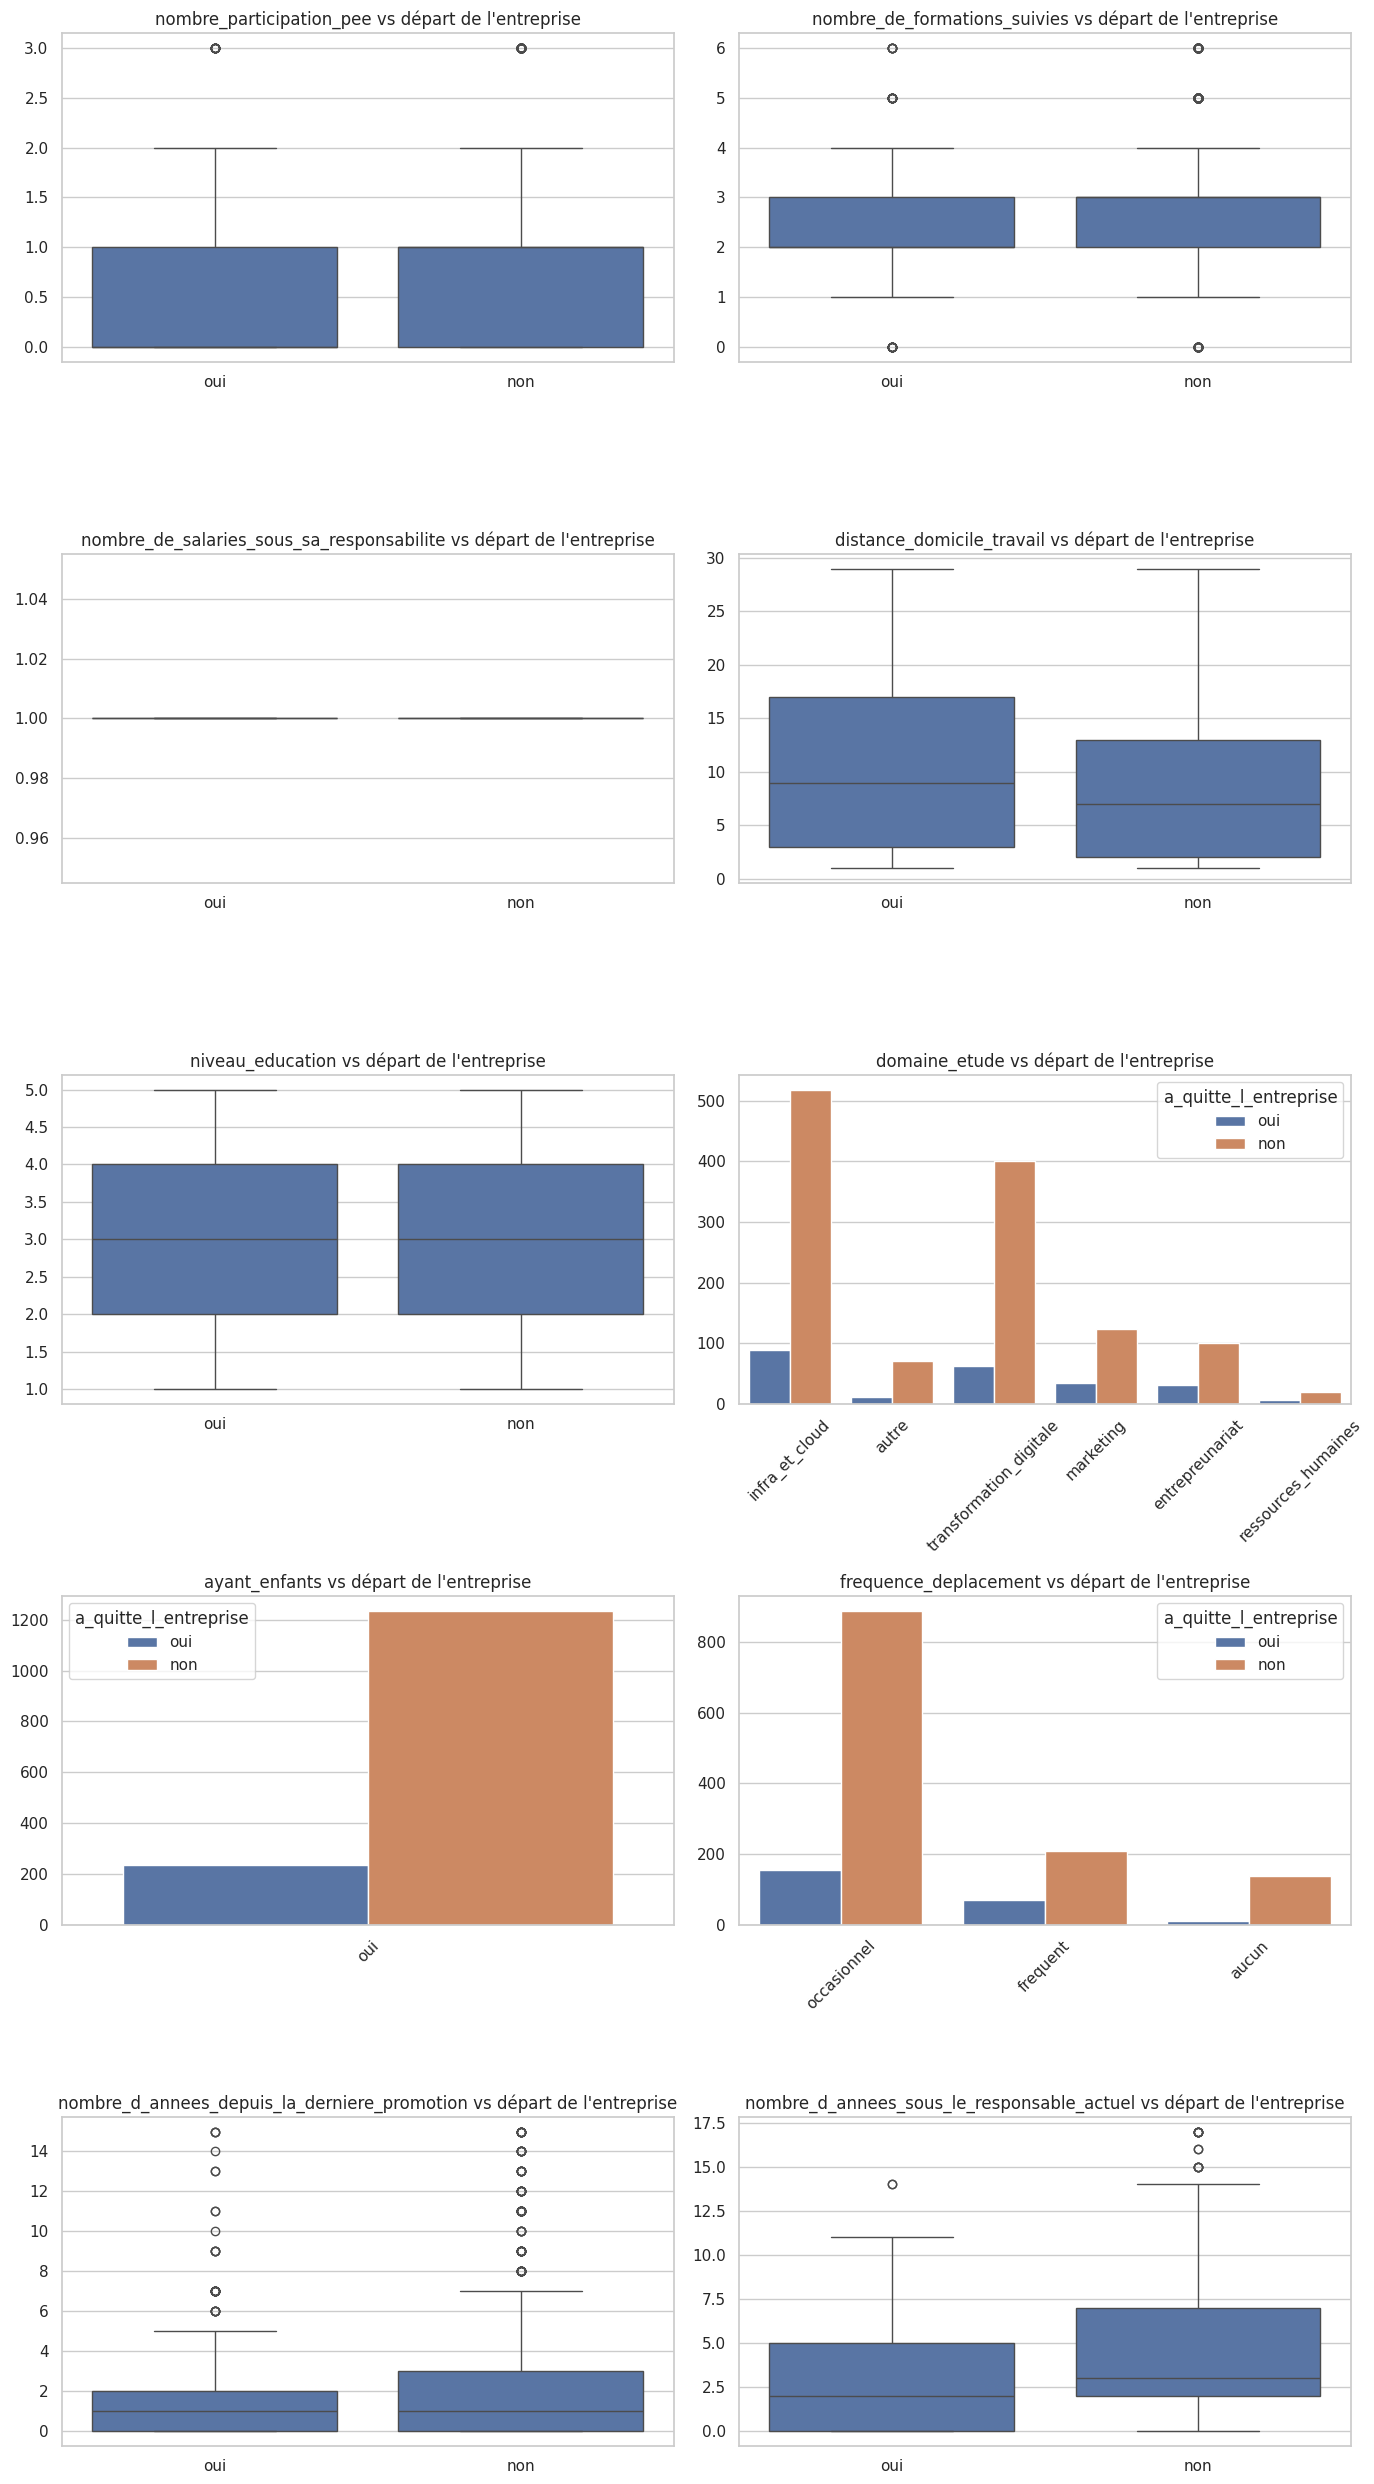

In [508]:
# visualisaitons bivariees
import math

sns.set(style="whitegrid")

cols = [
    "nombre_participation_pee",
    "nombre_de_formations_suivies",
    "nombre_de_salaries_sous_sa_responsabilite",
    "distance_domicile_travail",
    "niveau_education",
    "domaine_etude",
    "ayant_enfants",
    "frequence_deplacement",
    "nombre_d_annees_depuis_la_derniere_promotion",
    "nombre_d_annees_sous_le_responsable_actuel"
]

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    # Cas variables numériques
    if df_sondage[col].dtype == "int64":
        sns.boxplot(
            data=df_sondage,
            x="a_quitte_l_entreprise",
            y=col,
            ax=axes[i]
        )
    
    # Cas variables catégorielles
    else:
        sns.countplot(
            data=df_sondage,
            x=col,
            hue="a_quitte_l_entreprise",
            ax=axes[i]
        )
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} vs départ de l'entreprise")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# supprimer axes inutilisés
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### observations
* la colonne ayant enfants pourra être retirée du dataframe car la réponse est toujours oui, donc la variable n'apportera pas d'informations
* population plutôt proche du lieu de travail, peu de contrainte géographique globale
* politique de formation active (1000 salaries ont suivi entre 2 et 3 formations)
* promotions récentes nombreuses
* déplacements assez présents ce qui peut être facteur potentiel de fatigue puis de départ de l'entreprise
* population technique dominante
* Le dataset présente un déséquilibre de classes significatif sur la variable cible, ce qui nécessitera des techniques adaptées (pondération, rééchantillonnage avec undersampling) lors de la modélisation machine learning
* plus de départs dans le domaine “infra & cloud” (profils très demandés, stress, sous-payé par rapport au marché)

L’analyse exploratoire met en évidence une population majoritairement technique (domaine infra & cloud), avec une forte concentration des départs dans ce segment. Par ailleurs, les salariés présentent une ancienneté faible depuis leur dernière promotion et une fréquence de déplacement majoritairement occasionnelle. Le dataset présente également un déséquilibre de classes (16% de départs), ce qui devra être pris en compte dans les étapes de modélisation.

In [509]:
df_sondage.drop(
    columns=[
        "ayant_enfants",
        "nombre_de_salaries_sous_sa_responsabilite"
    ],
    inplace=True
)
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   a_quitte_l_entreprise                         1470 non-null   str  
 1   nombre_participation_pee                      1470 non-null   int64
 2   nombre_de_formations_suivies                  1470 non-null   int64
 3   code_sondage                                  1470 non-null   int64
 4   distance_domicile_travail                     1470 non-null   int64
 5   niveau_education                              1470 non-null   int64
 6   domaine_etude                                 1470 non-null   str  
 7   frequence_deplacement                         1470 non-null   str  
 8   nombre_d_annees_depuis_la_derniere_promotion  1470 non-null   int64
 9   nombre_d_annees_sous_le_responsable_actuel    1470 non-null   int64
dtypes: int64(7), str(3)
mem

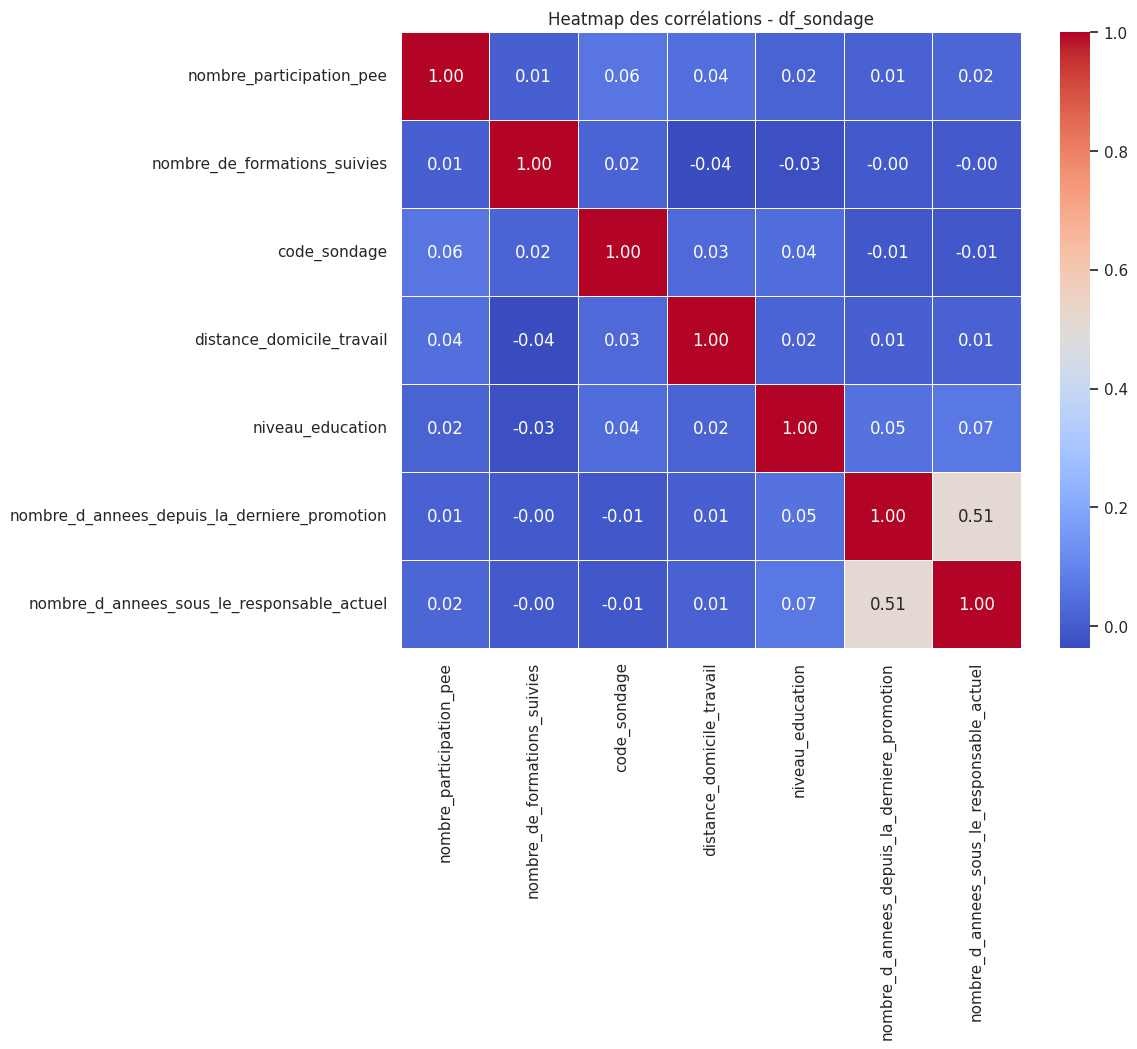

In [510]:
# Matrice globale des corrélations de df_sondage
# sélection des colonnes numériques
num_cols_sondage = df_sondage.select_dtypes(include="int64")

# matrice de corrélation
corr_matrix = num_cols_sondage.corr()

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap des corrélations - df_sondage")
plt.show()

#### observation
Une corrélation modérée (0.51) entre le nombre d’années depuis la dernière promotion et l’ancienneté avec le responsable actuel suggère que les salariés restés longtemps sous le même management ont tendance à connaître une progression de carrière plus lente, ce qui peut refléter une certaine stagnation professionnelle. Ceci peut être une motivation pour quitter l'entreprise.

In [511]:
# Réalisation de la jointure pour réunir les trois dataframes

df_sirh = df_sirh.rename(columns={"id_salarie": "id"})
df_eval = df_eval.rename(columns={"numero_d_evaluation": "id"})
df_sondage = df_sondage.rename(columns={"code_sondage": "id"})

df_joint = (
    df_sirh
    .merge(df_eval, on="id", how="inner")
    .merge(df_sondage, on="id", how="inner")
    .sort_values(by="id")
    .reset_index(drop=True)
)

In [512]:
# Contrôle dimensions du dataframe obtenu et de l'absence de doublons
print("Shape finale :", df_joint.shape)
print("Doublons :", df_joint.duplicated().sum())

Shape finale : (1470, 31)
Doublons : 0


In [513]:
df_joint.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   id                                            1470 non-null   int64   
 1   age                                           1470 non-null   int64   
 2   genre                                         1470 non-null   str     
 3   revenu_mensuel                                1470 non-null   int64   
 4   statut_marital                                1470 non-null   str     
 5   departement                                   1470 non-null   str     
 6   poste                                         1470 non-null   str     
 7   nombre_experiences_precedentes                1470 non-null   int64   
 8   nombre_total_annees_experience                1470 non-null   int64   
 9   nombre_total_annees_dans_l_entreprise         1470 non-null   i

#### EDA sur le dataframe df_joint (Im here)

In [514]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [515]:
df_joint.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1470.0,1024.865306,602.024335,1.0,491.25,1020.50,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.00,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.00,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.00,4.00,9.0
nombre_total_annees_experience,1470.0,11.279592,7.780782,0.0,6.00,10.00,15.00,40.0
nombre_total_annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.00,9.00,40.0
nombre_total_annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.00,7.00,18.0
satisfaction_salarie_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.00,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.00,3.00,4.0
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.0,1.00,2.00,3.00,5.0


In [516]:
# Fonctions python pour l'EDA sur le dataframe df_joint issu de la jointure

def eda_univariee(df, num_cols=None, cat_cols=None):
    """Visualisations univariées pour les colonnes numériques et catégorielles"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques
    for col in num_cols:
        sns.histplot(df[col], kde=False)
        plt.title(f"Distribution de {col}")
        plt.show()
    
    # Catégorielles
    for col in cat_cols:
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.show()


def eda_bivariee(df, target_col, num_cols=None, cat_cols=None):
    """Visualisations bivariées entre features et la cible"""
    if num_cols is None:
        num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    if cat_cols is None:
        cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Numériques vs cible
    for col in num_cols:
        sns.boxplot(x=df[target_col], y=df[col])
        plt.title(f"{col} selon {target_col}")
        plt.show()
    
    # Catégorielles vs cible
    for col in cat_cols:
        sns.countplot(x=col, hue=target_col, data=df)
        plt.title(f"{col} selon {target_col}")
        plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

def correlation_heatmap(df, method="pearson"):
    """
    Affiche une heatmap de corrélation.
    - method="pearson" : variables normalement distribuées
    - method="spearman": variables non normales ou discrètes
    """
    if method == "pearson":
        cols = [
            "age"  
        ]
    elif method == "spearman":
        cols = [
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "precedent_pourcentage_d_augmentation",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel"
        ]
    else:
        raise ValueError("Méthode doit être 'pearson' ou 'spearman'")

    #plt.figure(figsize=(12,10))
    #sns.heatmap(df[cols].corr(method=method), annot=True, fmt=".2f", cmap="coolwarm")
    #plt.title(f"Matrice de corrélation ({method})")
    #plt.show()

    plt.figure(figsize=(18,14))  # Figure plus grande

    sns.heatmap(
    df[cols].corr(method=method),
    annot=True,           # afficher les valeurs
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},  # taille du texte dans les cases
    linewidths=0.5          # espace entre les cases
)

    plt.title(f"Matrice de corrélation ({method})", fontsize=16)
    plt.xticks(fontsize=10, rotation=45)  # taille et rotation des labels x
    plt.yticks(fontsize=10, rotation=0)   # taille et rotation des labels y
    plt.tight_layout()                    # ajuste la figure pour éviter le chevauchement   
    plt.show()


def pairplot_sample(df, cols, target_col, sample_size=500):
    """Pairplot pour un sous-échantillon du dataframe"""
    if len(df) > sample_size:
        df_sample = df.sample(sample_size, random_state=42)
    else:
        df_sample = df
    sns.pairplot(df_sample[cols + [target_col]], hue=target_col, diag_kind="kde")
    plt.show()

In [517]:
# Fonctions python pour préparer les features X et la target y à partir de df_joint

def prepare_features(df, target_col):
    """
    Prépare X et y pour sklearn :
    - encode la cible en binaire
    - sépare features numériques et catégorielles
    - encode les catégorielles avec OneHotEncoder
    """
    # Cible
    y = df[target_col].map({"Oui":1, "Non":0})  # ajuster selon vos valeurs

    # Features
    X = df.drop(columns=[target_col, "id"])  # on enlève id et cible

    # Colonnes catégorielles
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    # OneHotEncoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X_encoded, y

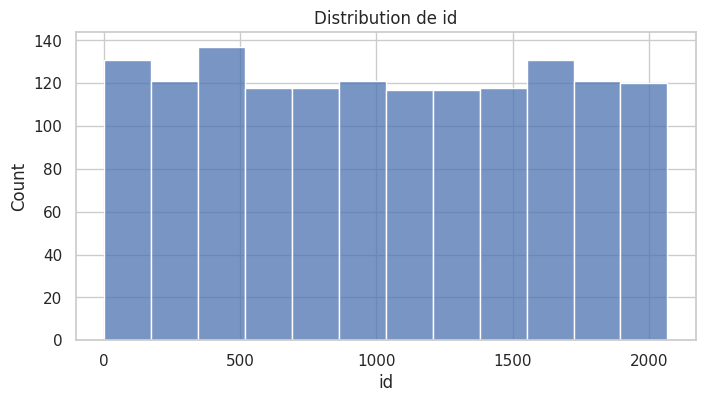

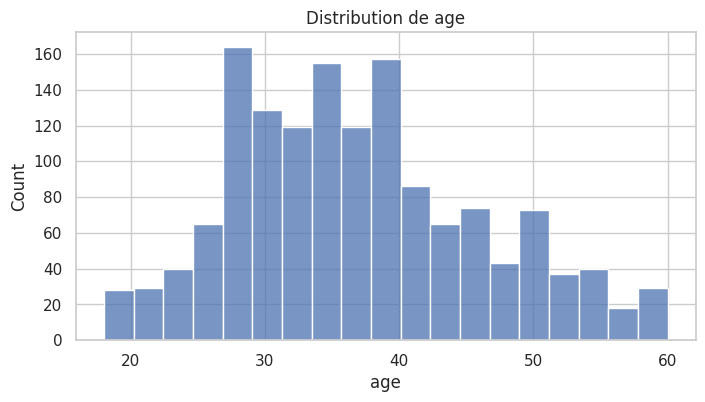

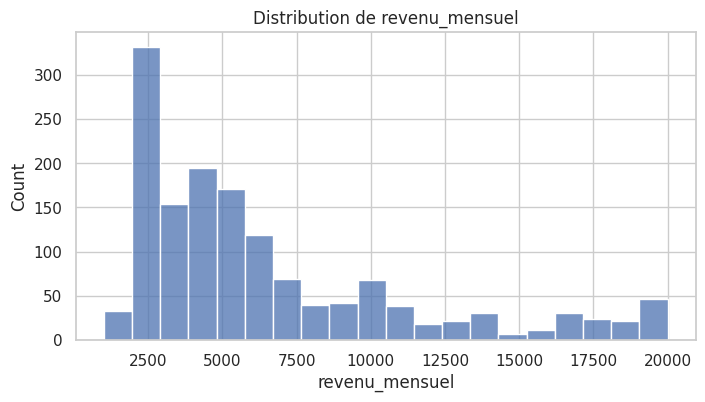

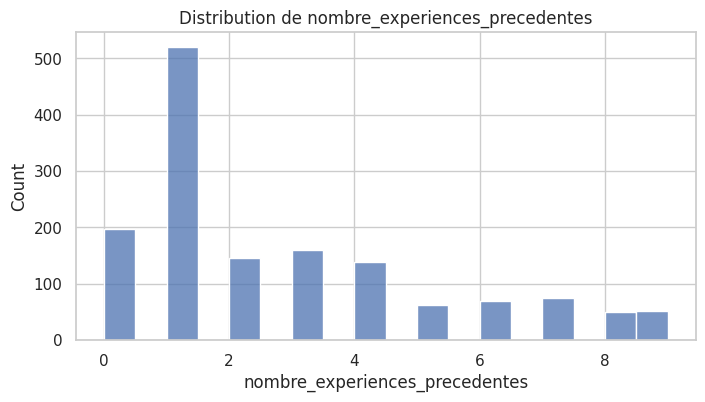

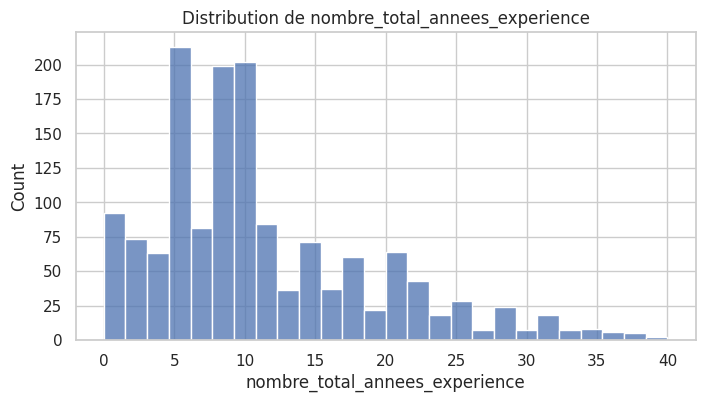

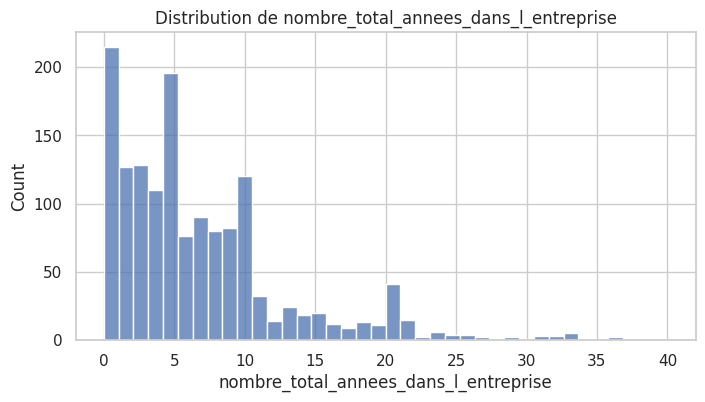

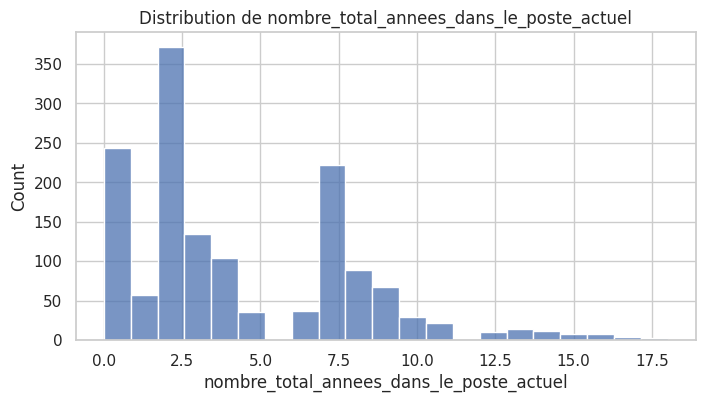

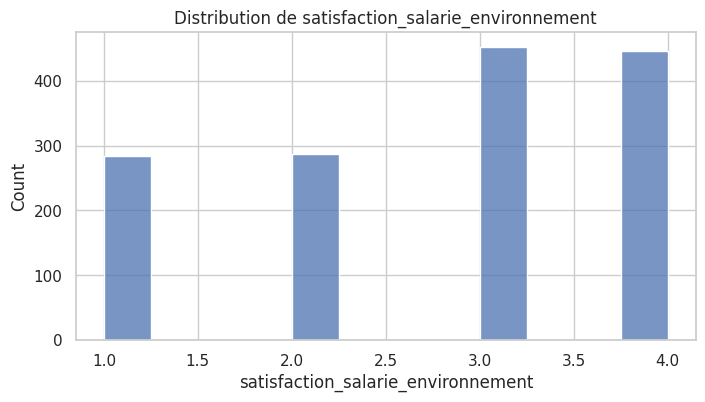

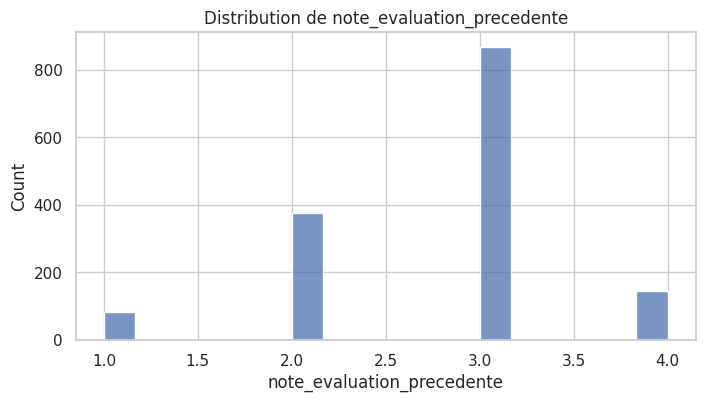

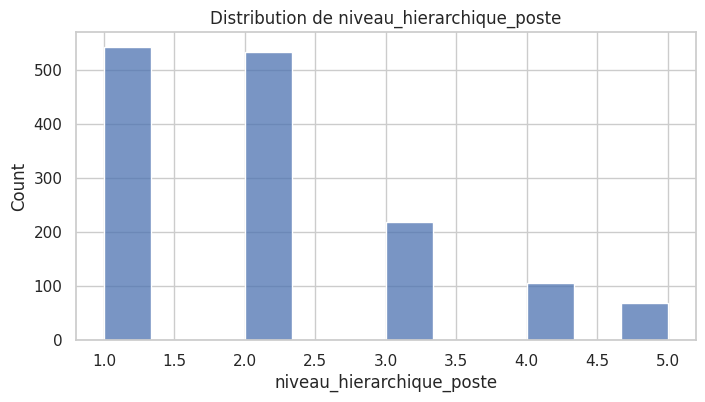

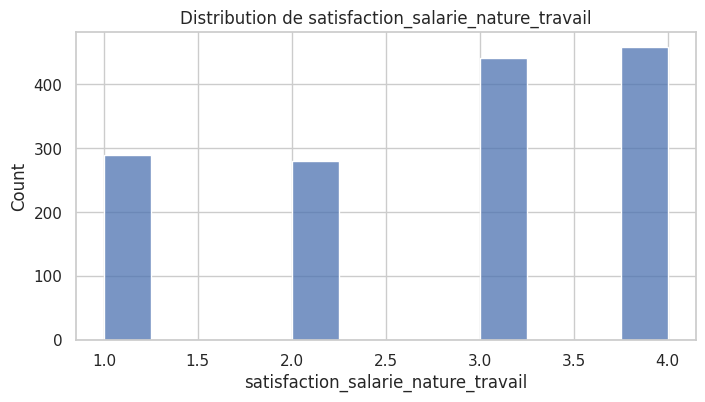

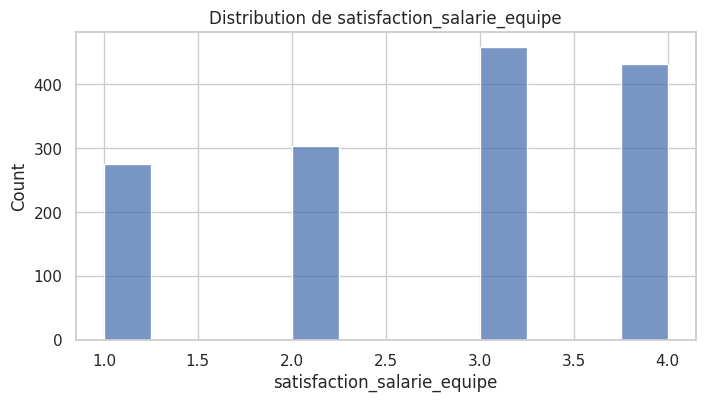

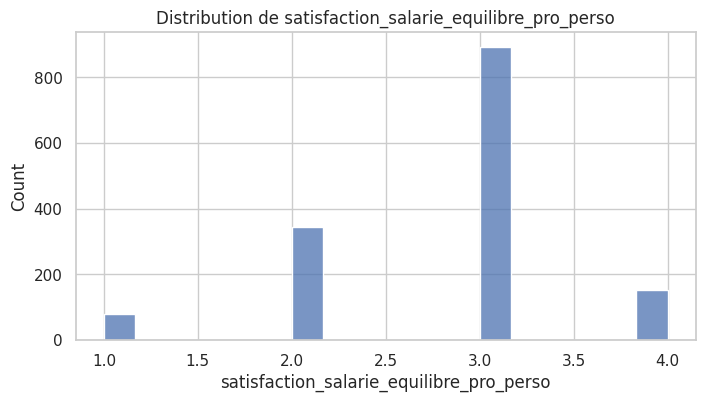

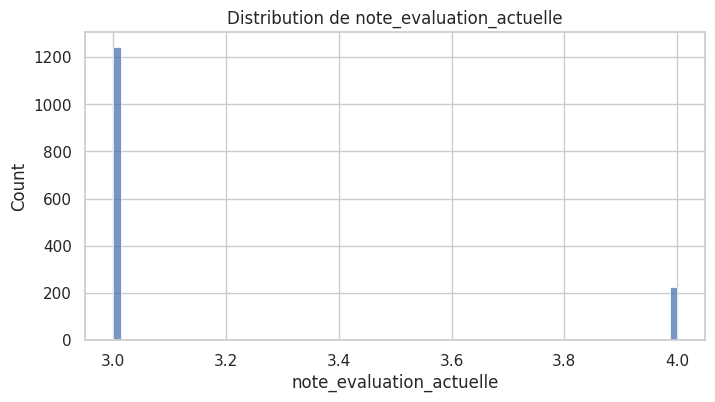

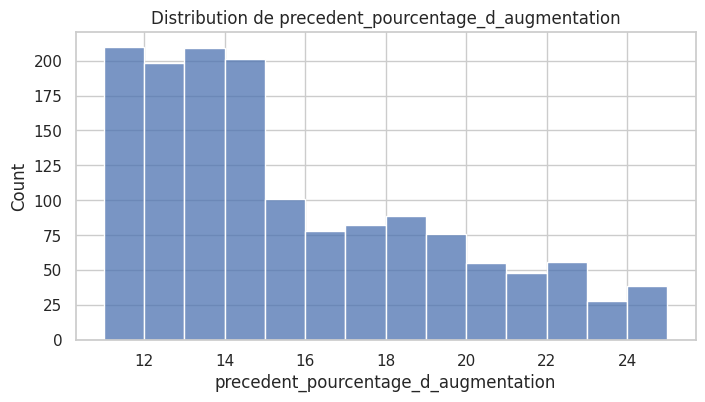

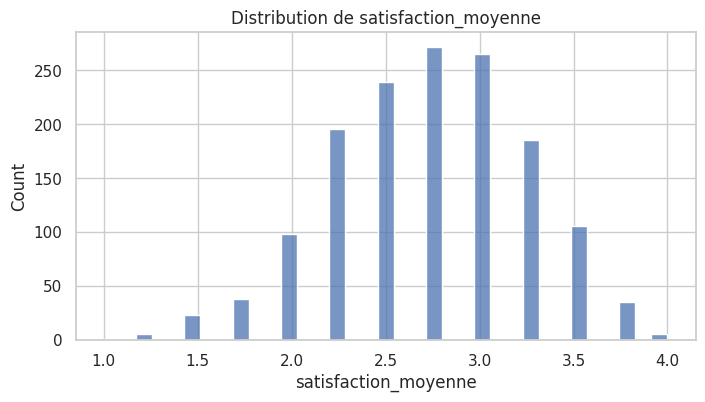

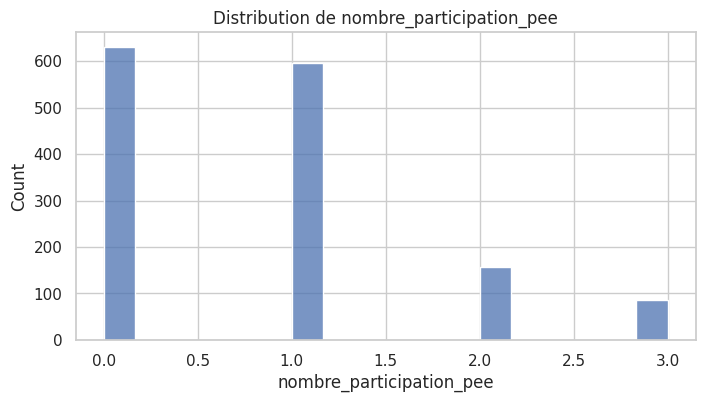

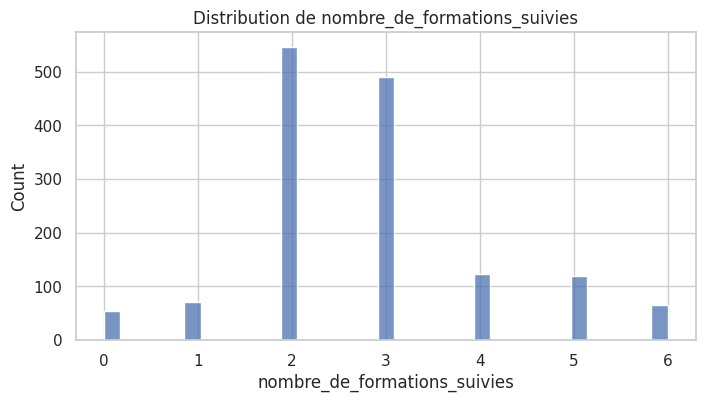

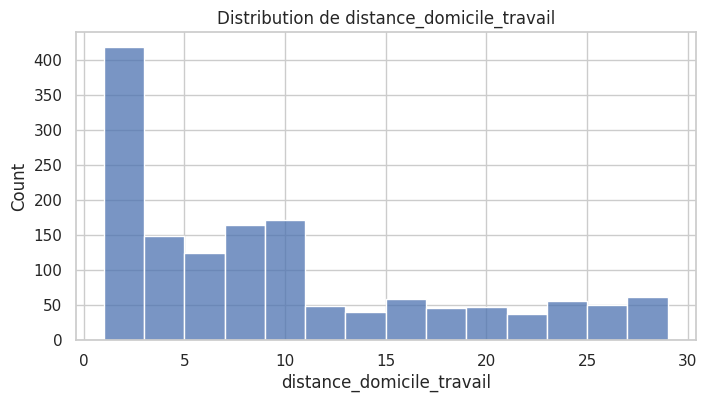

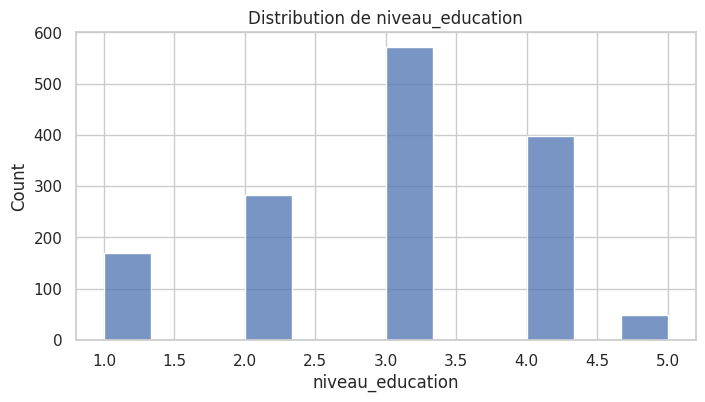

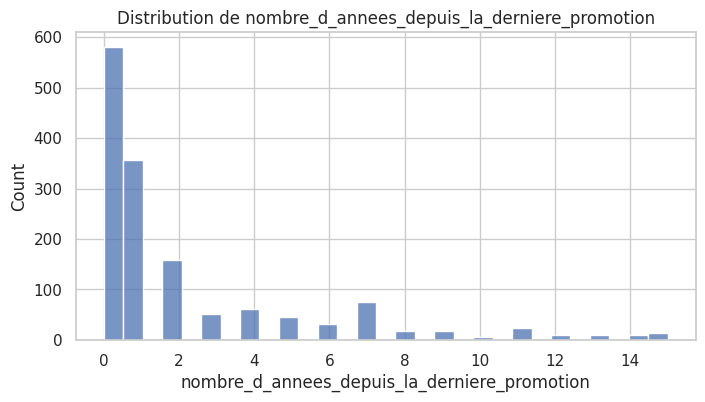

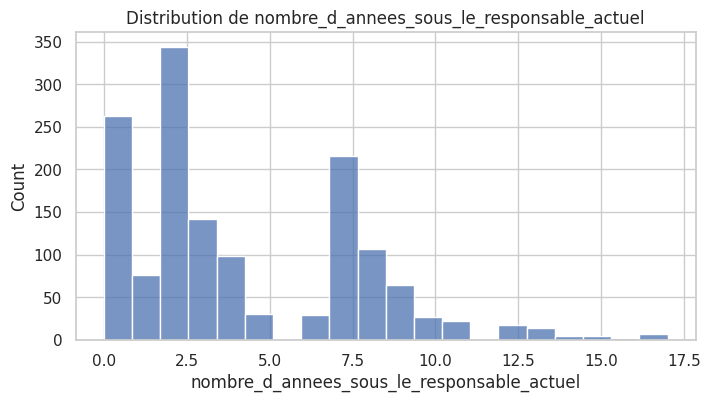

In [518]:
# EDA univariée

# On enlève l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]

# Sélection des colonnes numériques uniquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns

# Appel de la fonction univariée avec ces colonnes
eda_univariee(df_joint, num_cols=num_cols, cat_cols=[])

/tmp/ipykernel_35275/486934272.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_joint.select_dtypes(include=["object", "category"]).columns.tolist()


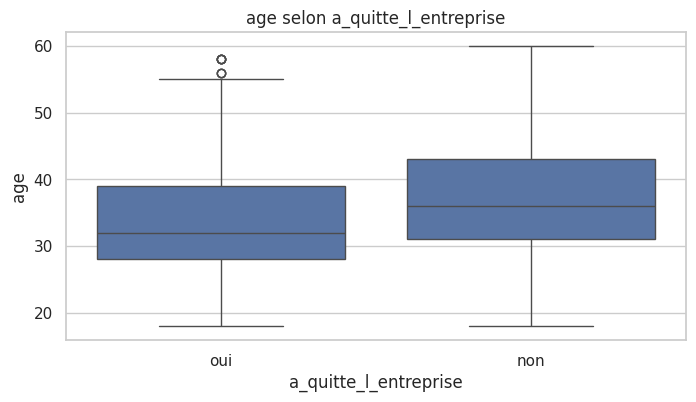

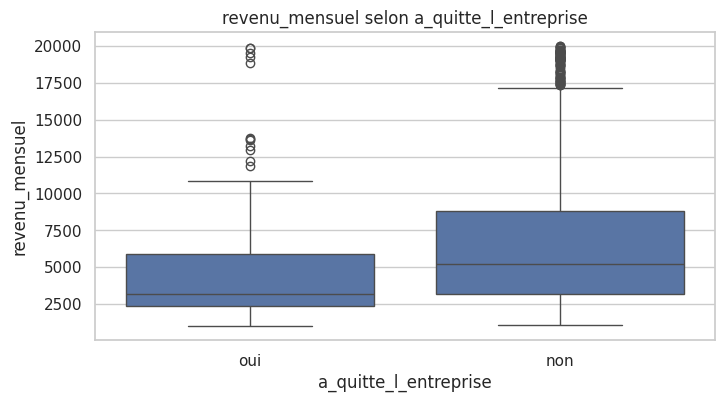

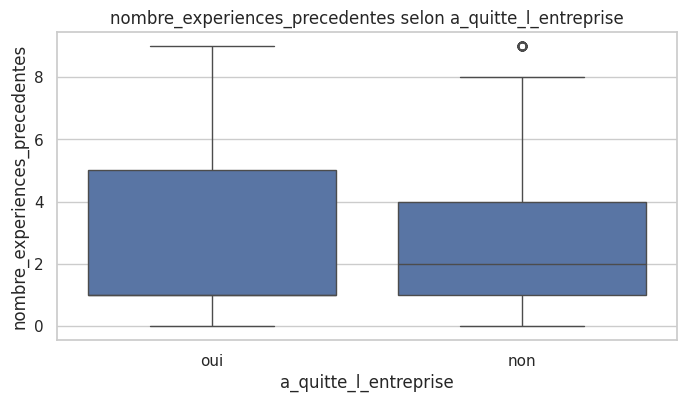

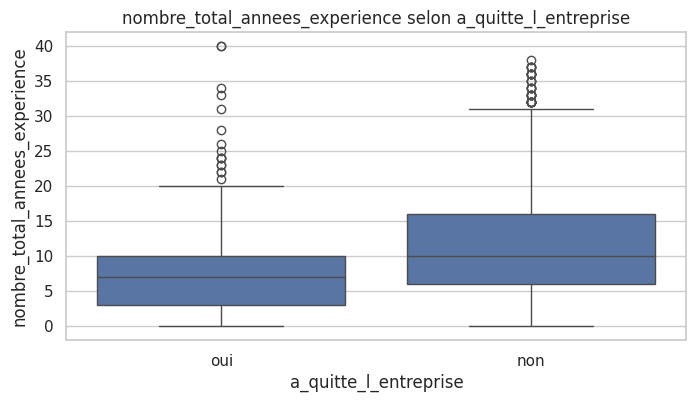

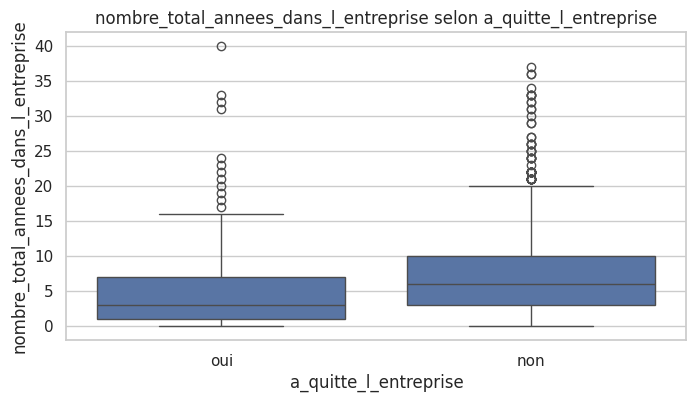

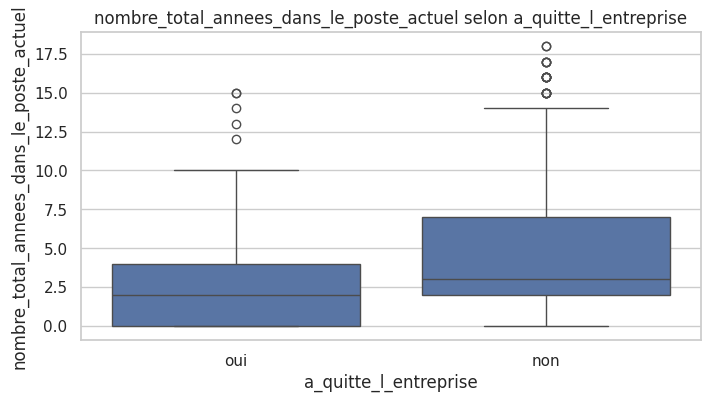

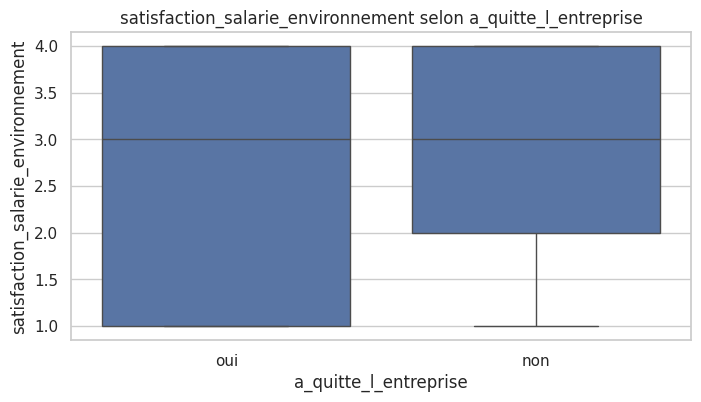

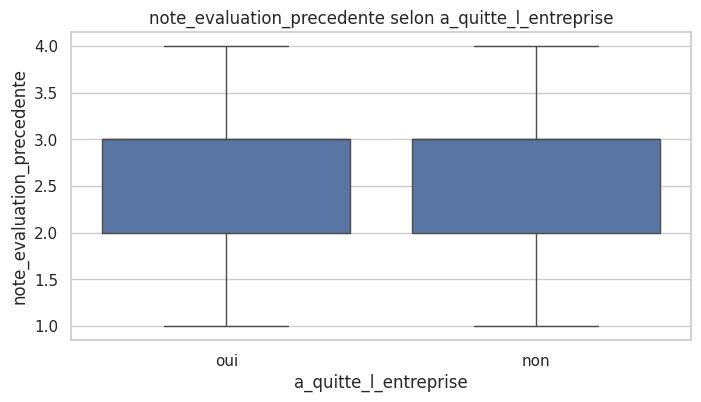

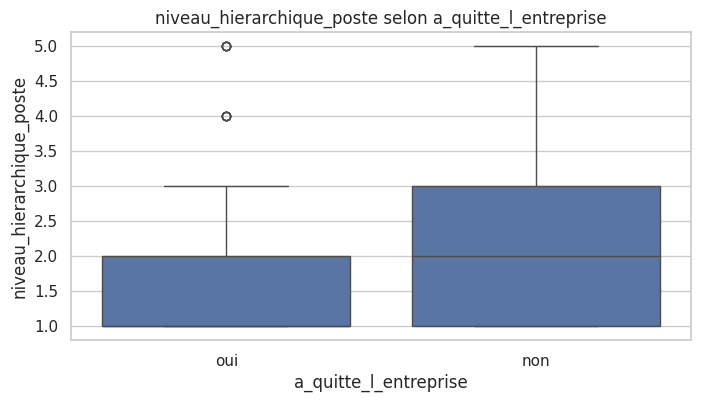

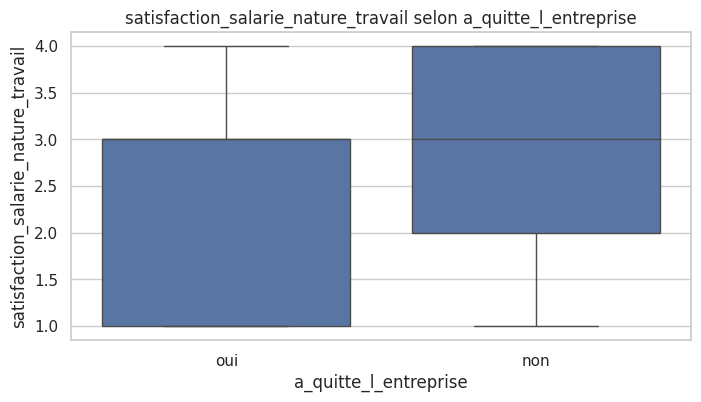

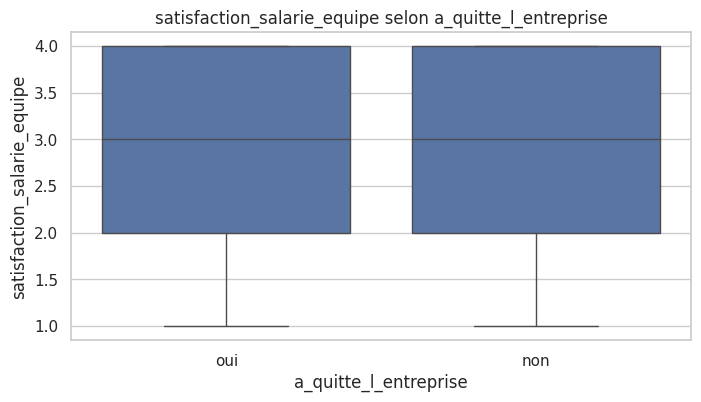

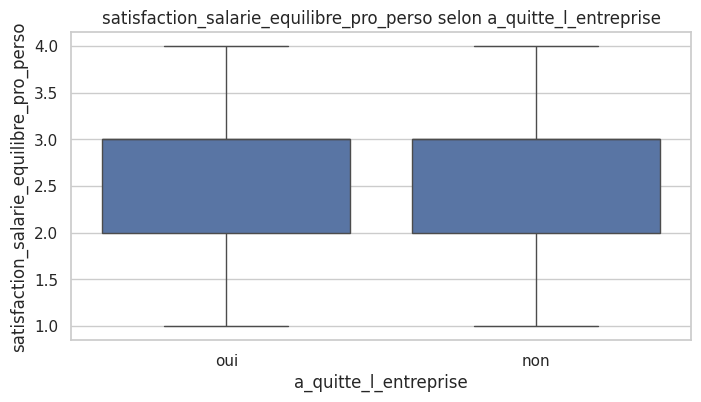

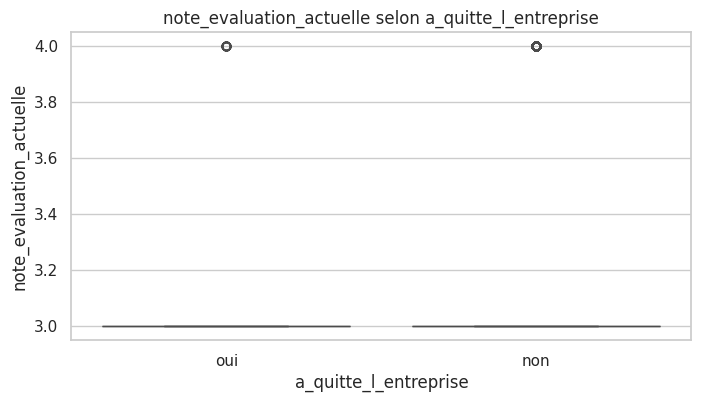

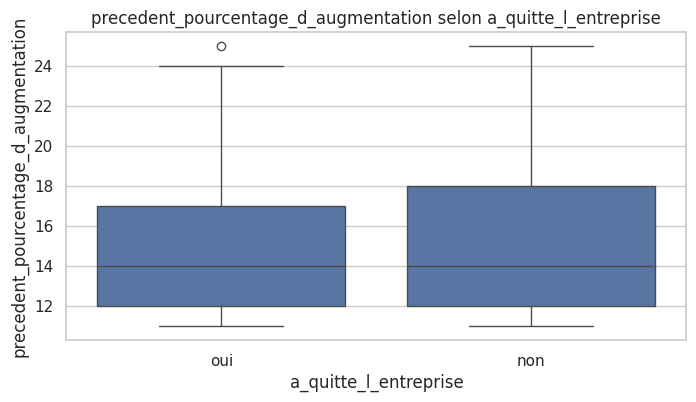

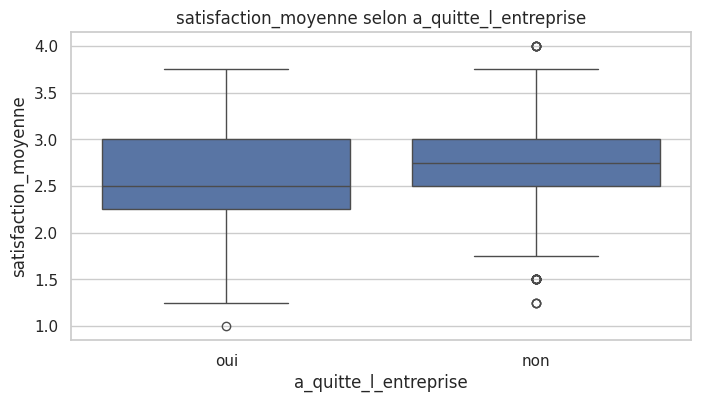

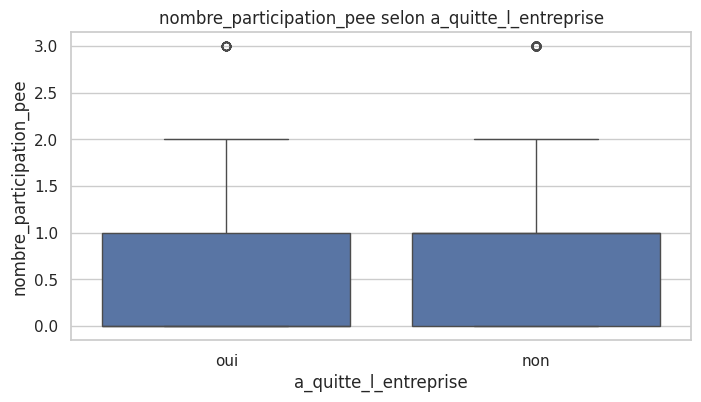

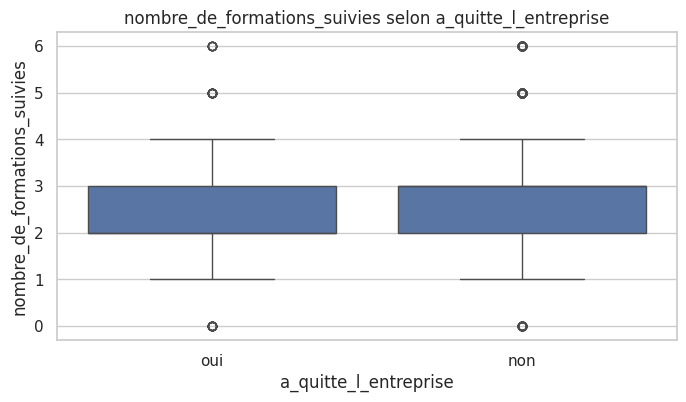

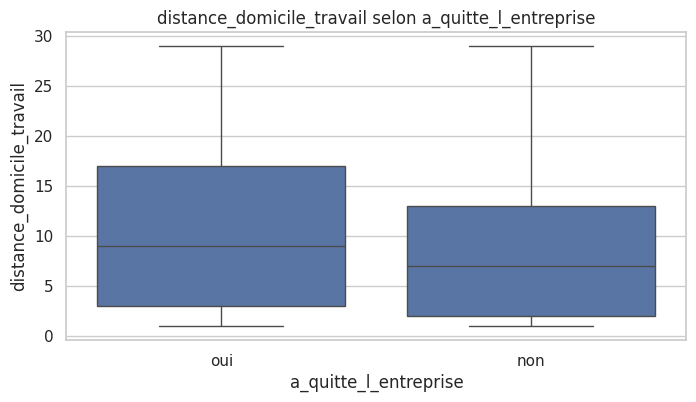

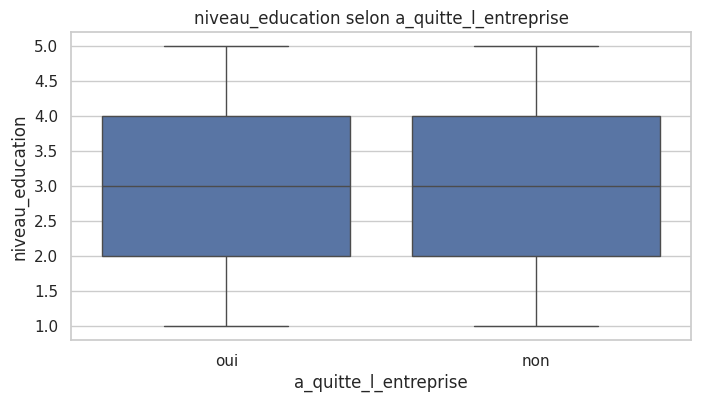

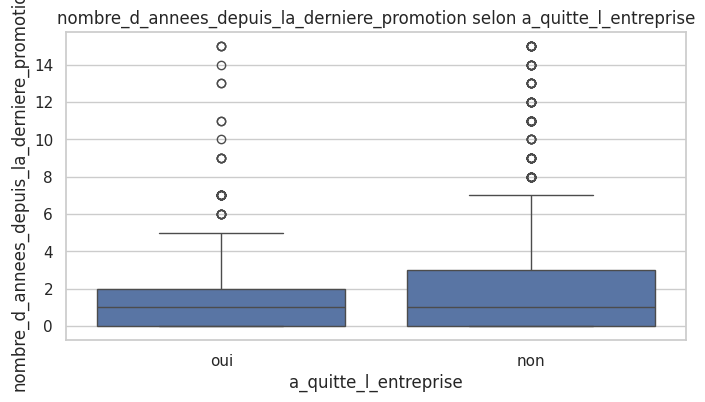

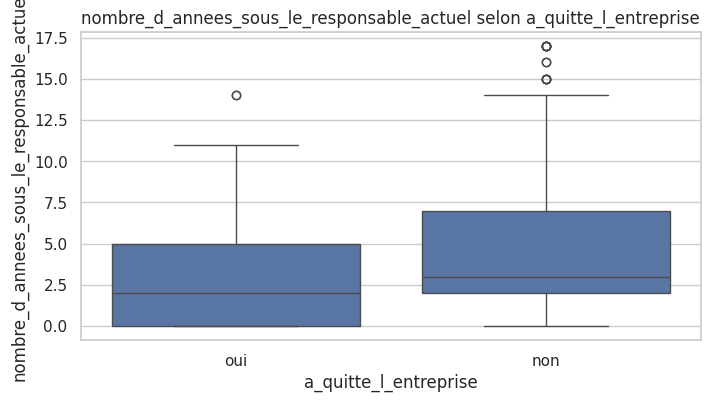

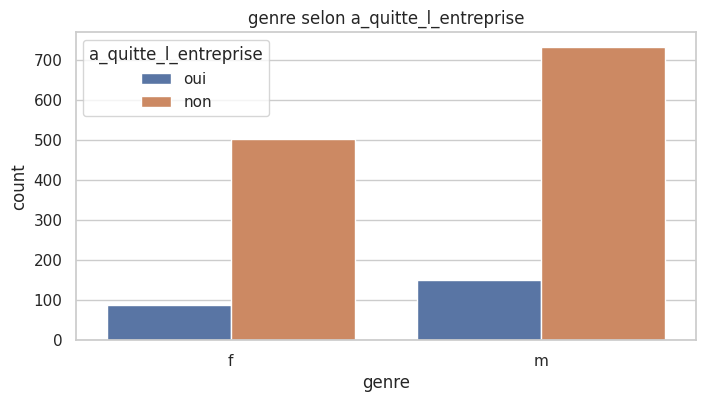

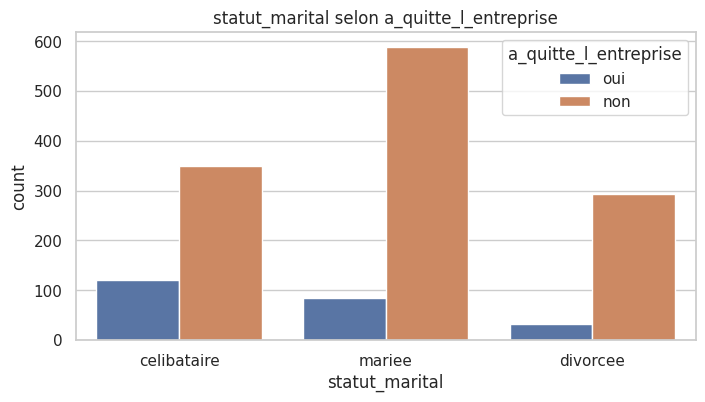

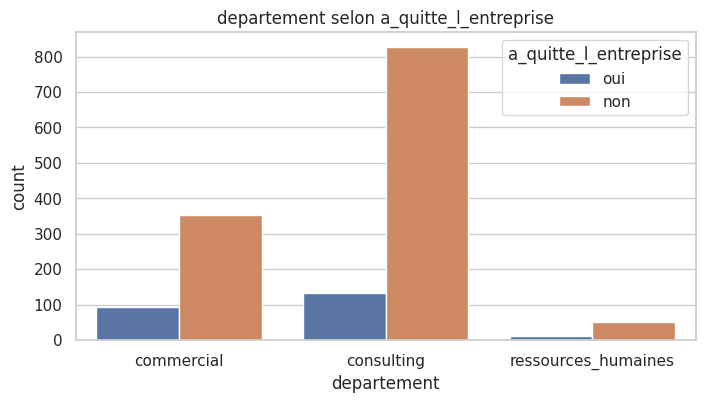

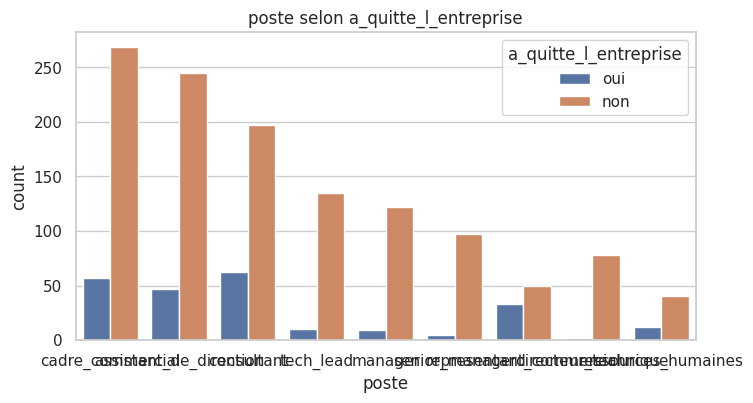

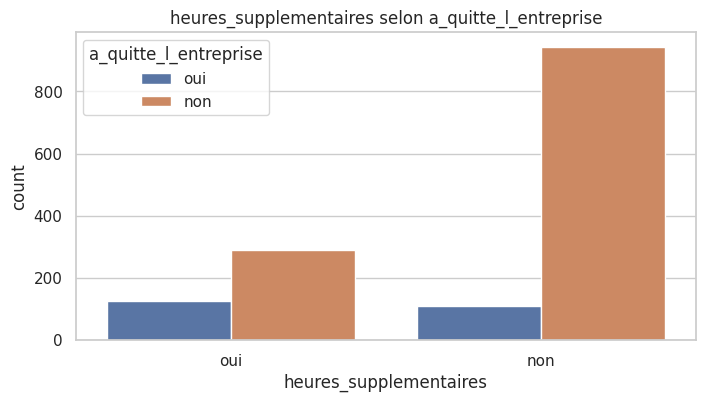

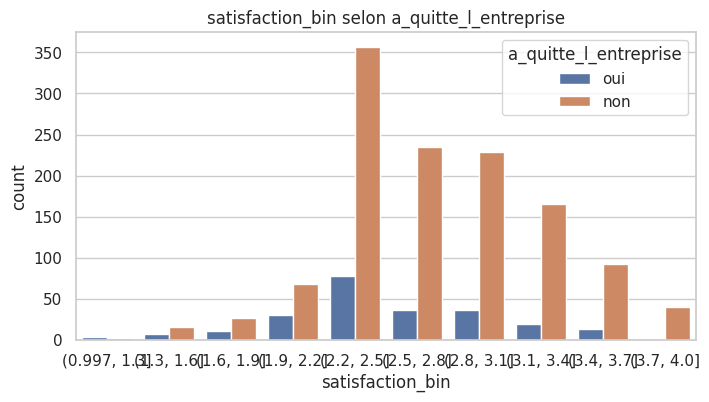

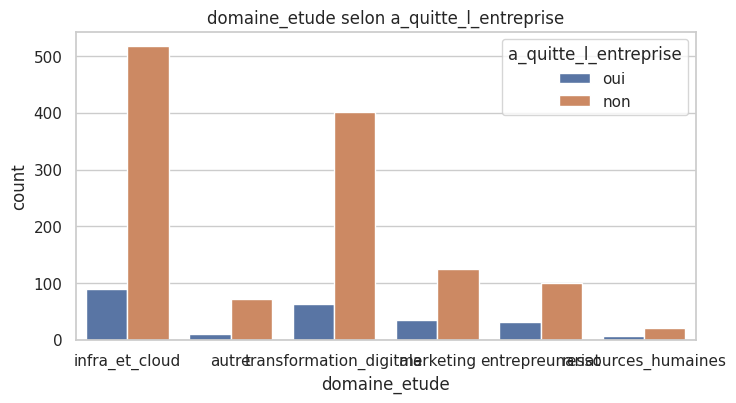

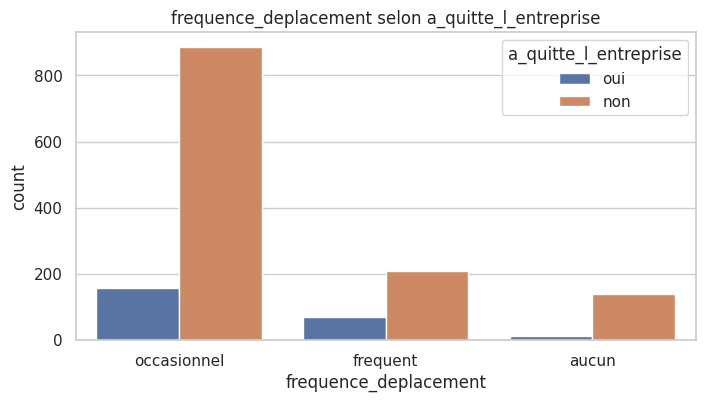

In [519]:
# EDA bivariée

# Détecter colonnes numériques et catégorielles automatiquement
num_cols = df_joint.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_joint.select_dtypes(include=["object", "category"]).columns.tolist()

# On enlève la cible et l'id des listes
num_cols = [col for col in num_cols if col not in ["id"]]
cat_cols = [col for col in cat_cols if col not in ["id", "a_quitte_l_entreprise"]]

# Lancer l'EDA bivariée
eda_bivariee(df_joint, target_col="a_quitte_l_entreprise", num_cols=num_cols, cat_cols=cat_cols)

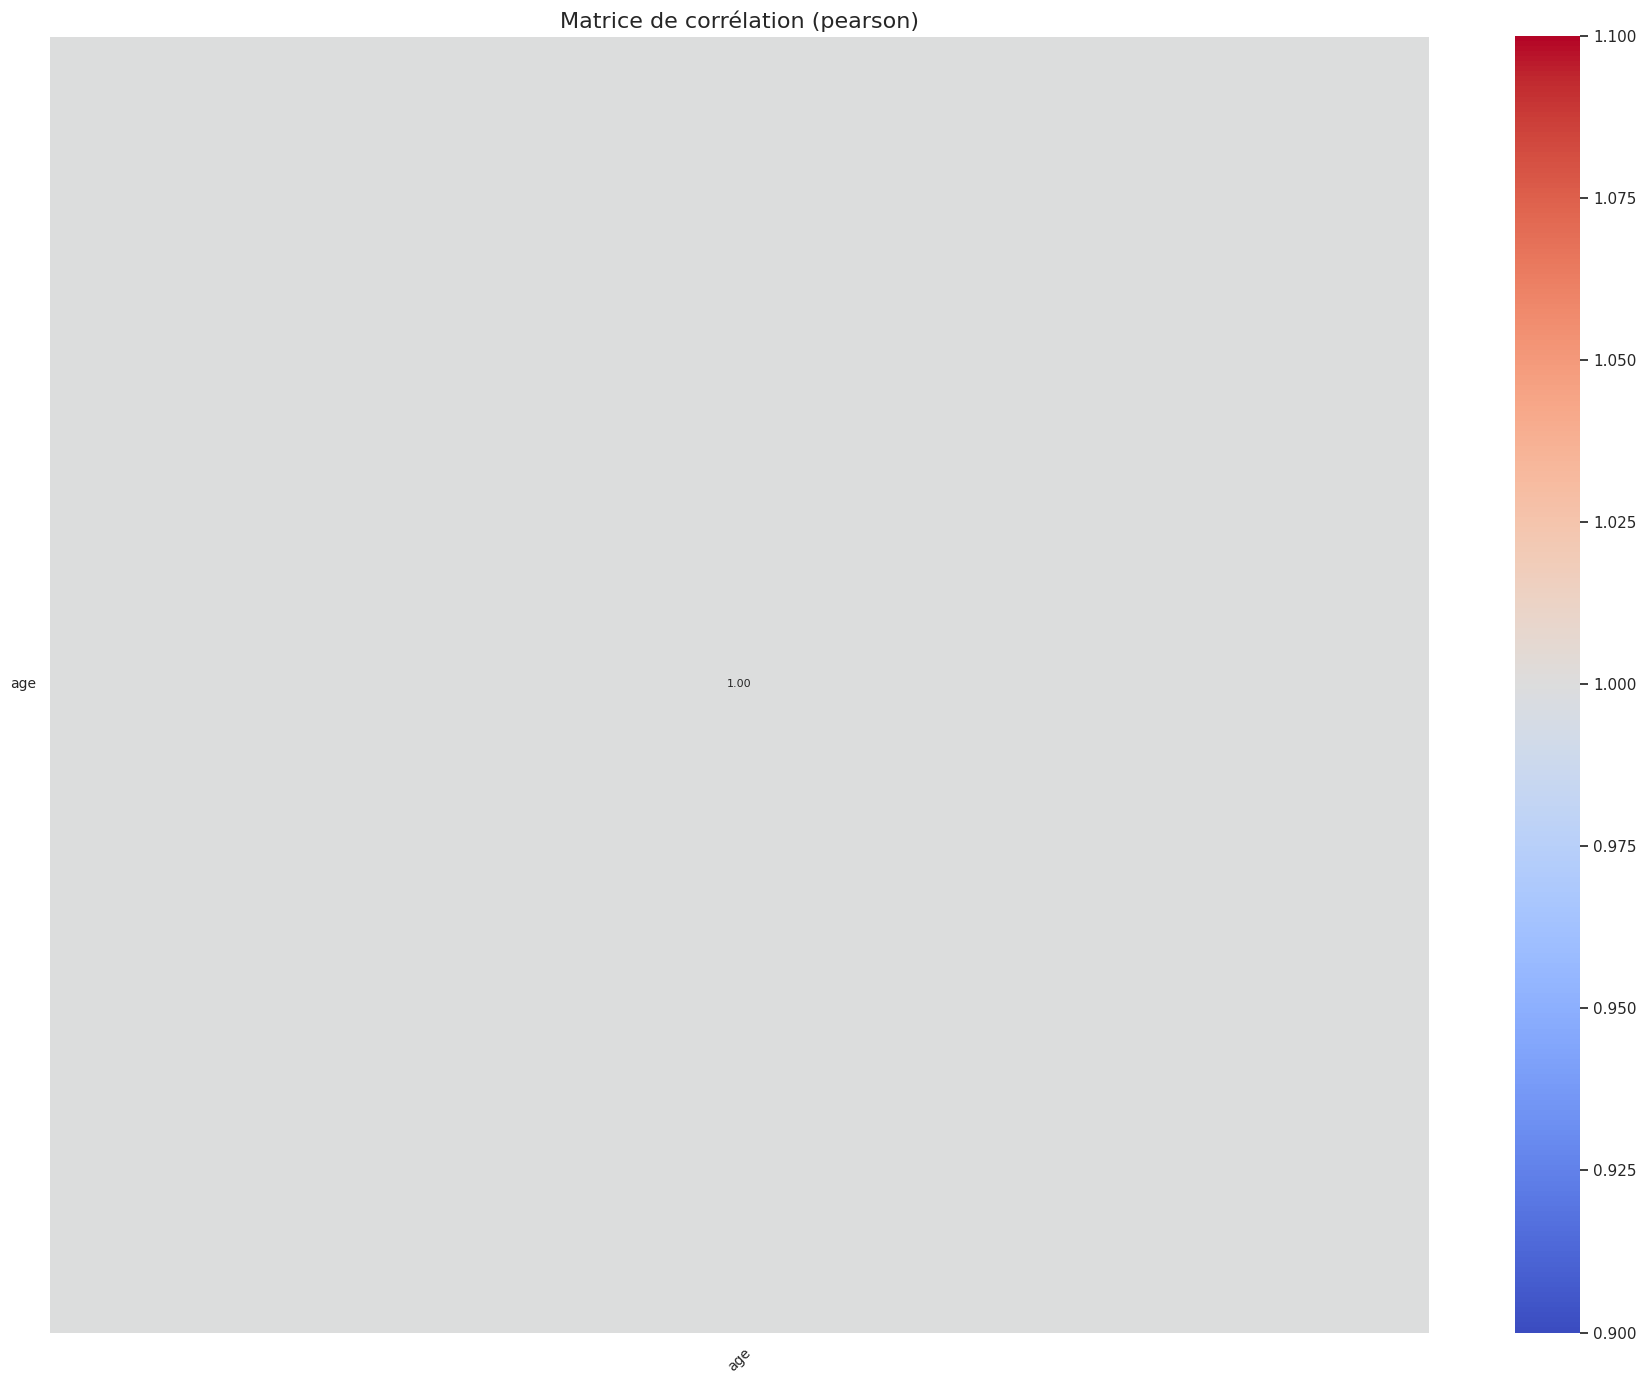

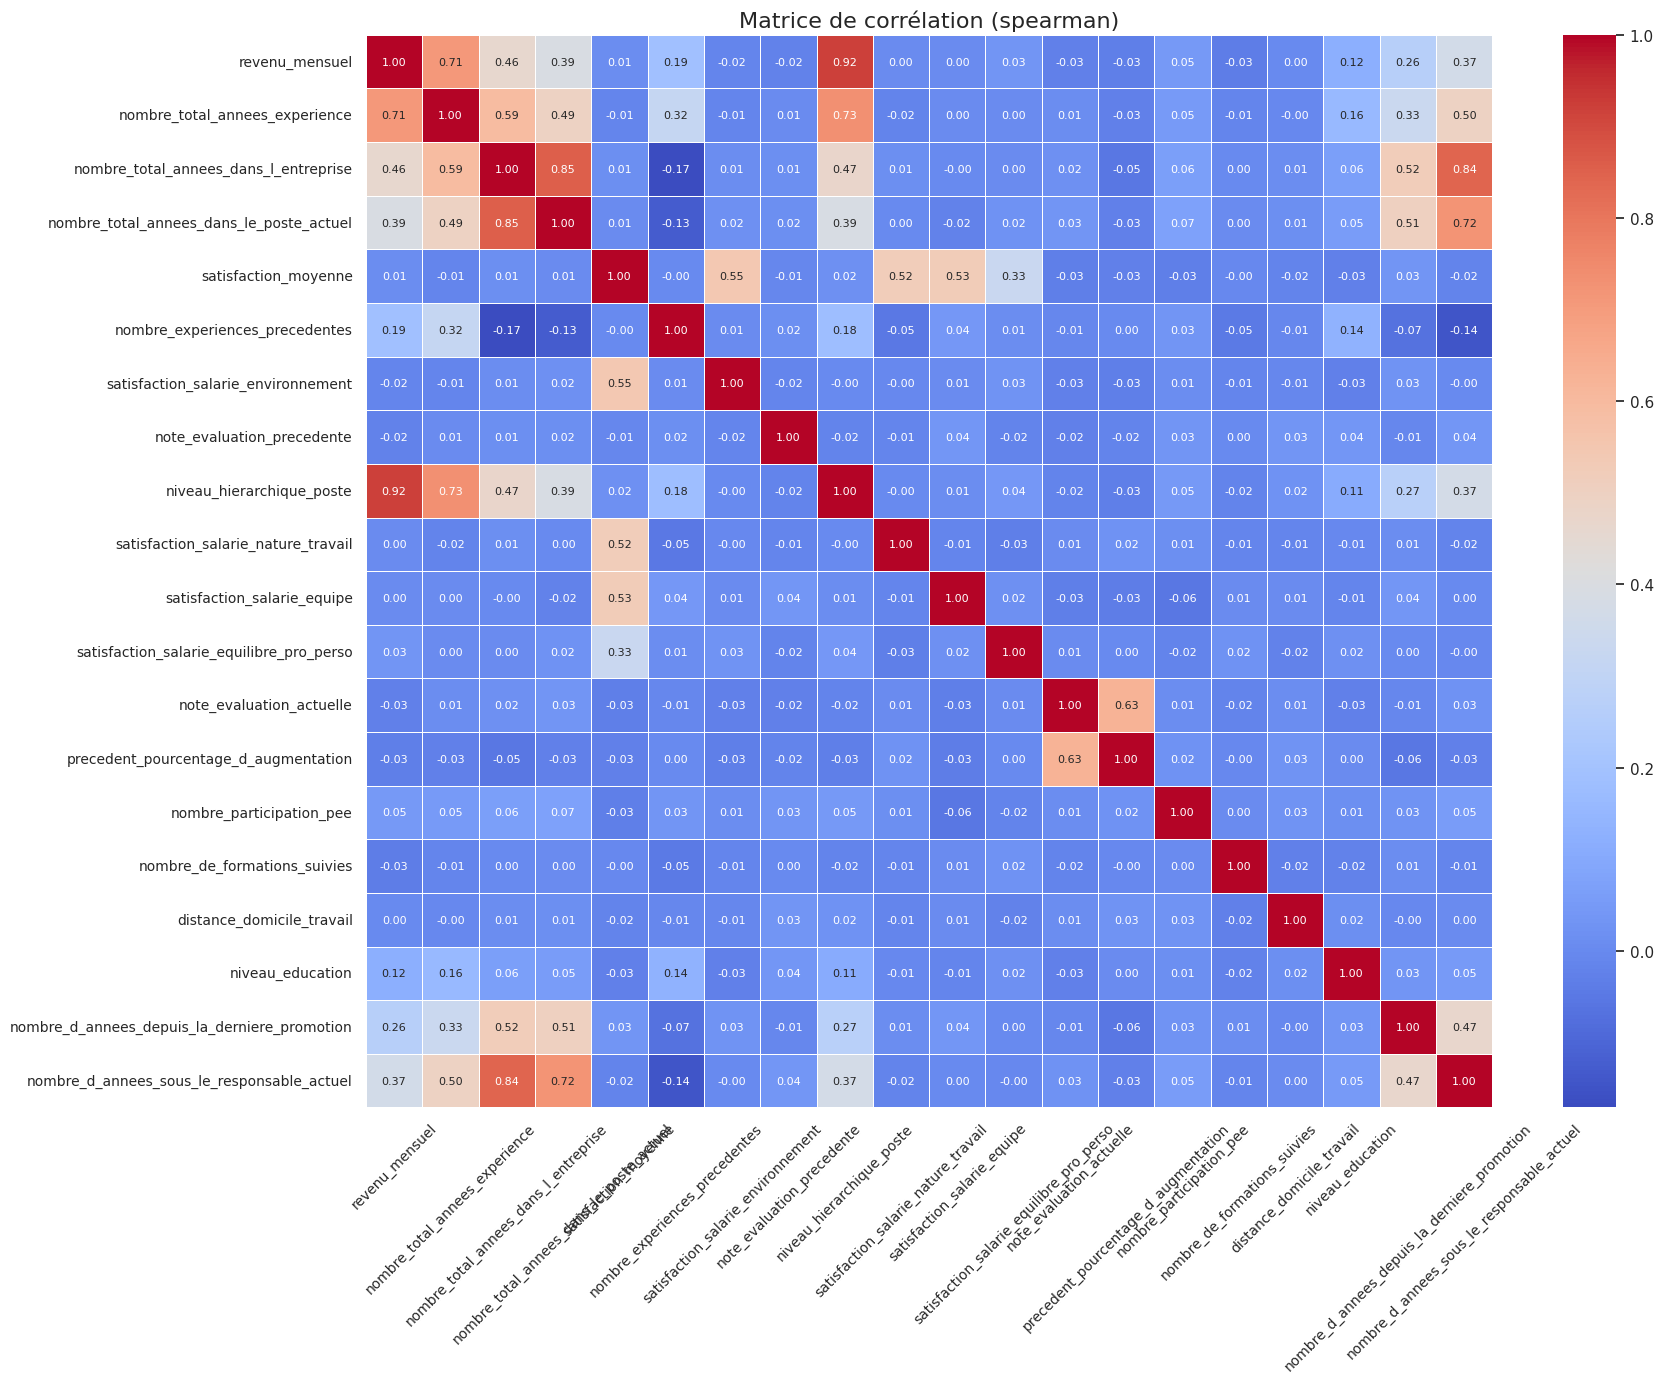

In [520]:
# Pearson pour variables continues/normales
correlation_heatmap(df_joint, method="pearson")

# Spearman pour variables discrètes/non normales
correlation_heatmap(df_joint, method="spearman")

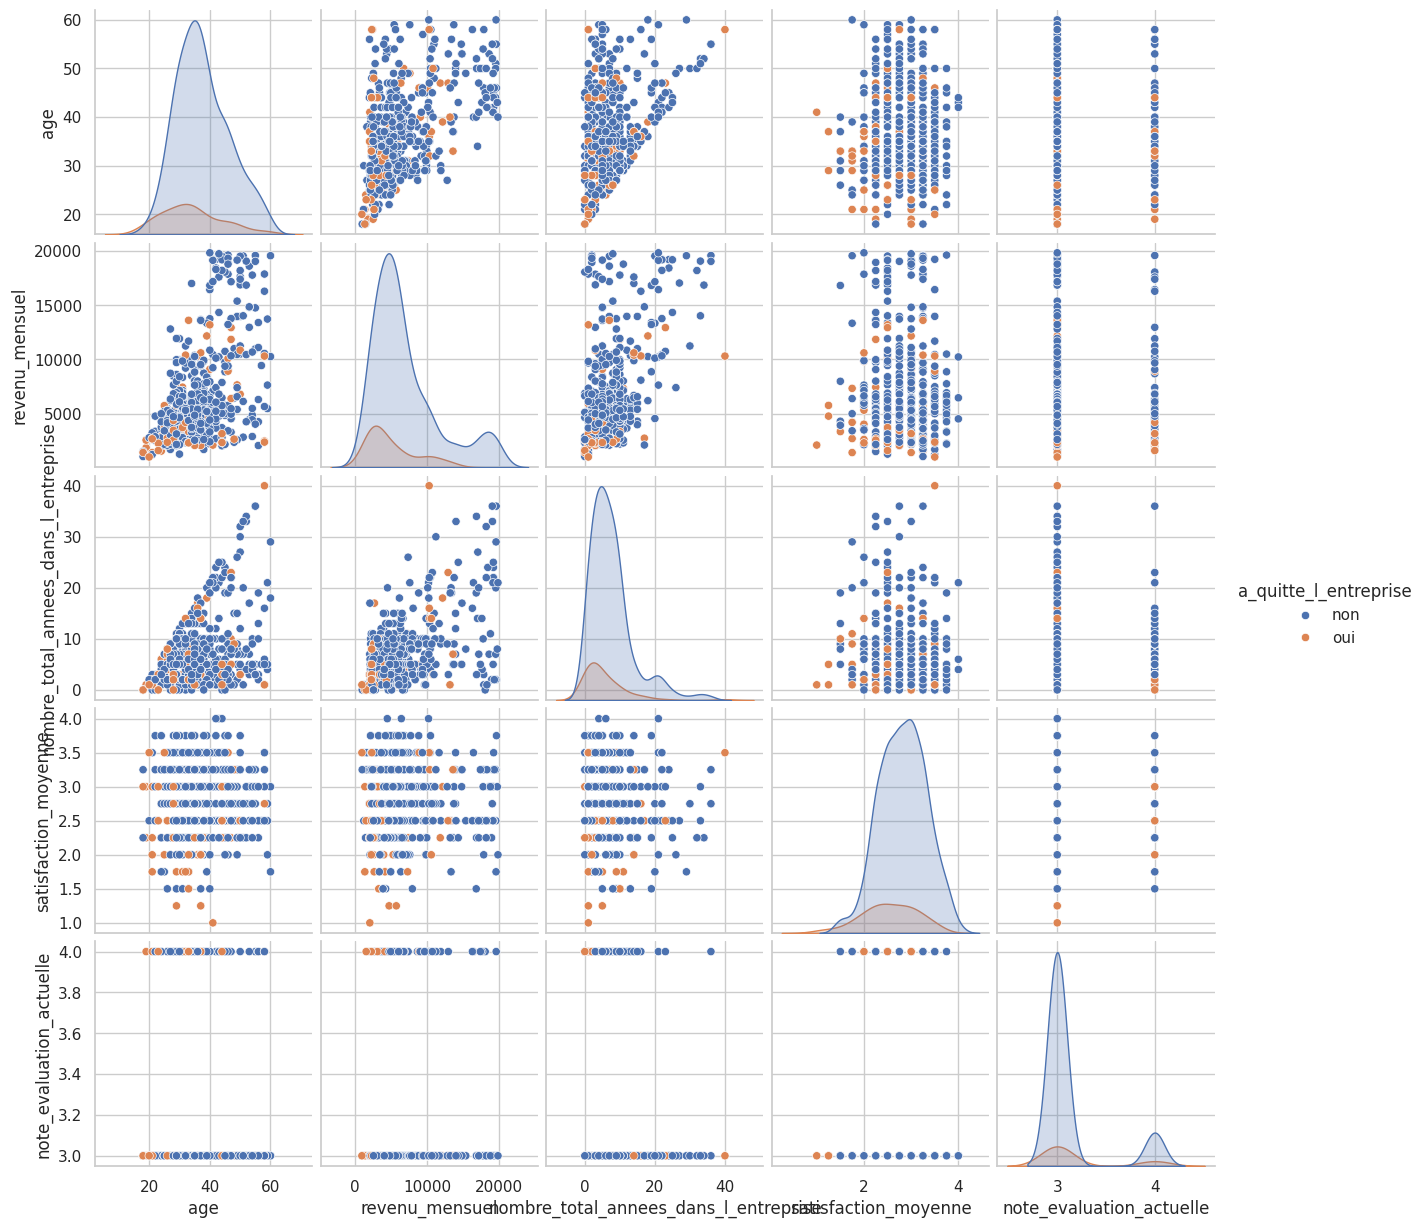

In [521]:
# Pairplot pour les variables clés

# Choisir les variables numériques les plus pertinentes
selected_cols = [
    "age", 
    "revenu_mensuel",
    "nombre_total_annees_dans_l_entreprise",
    "satisfaction_moyenne",
    "note_evaluation_actuelle"
]

pairplot_sample(df_joint, cols=selected_cols, target_col="a_quitte_l_entreprise", sample_size=500)

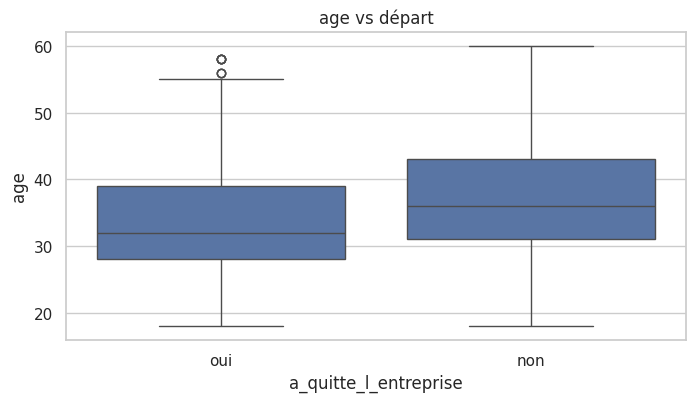

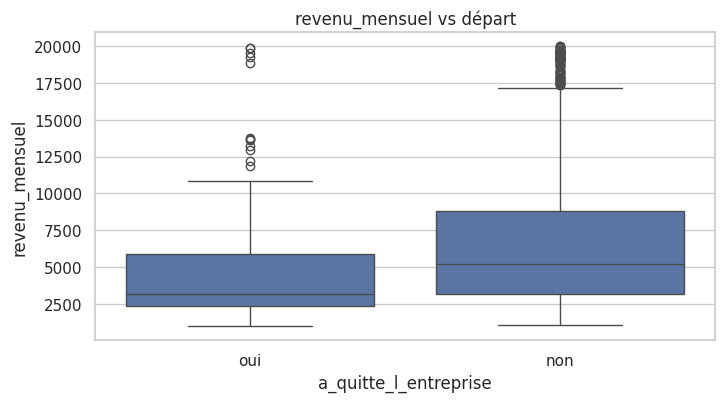

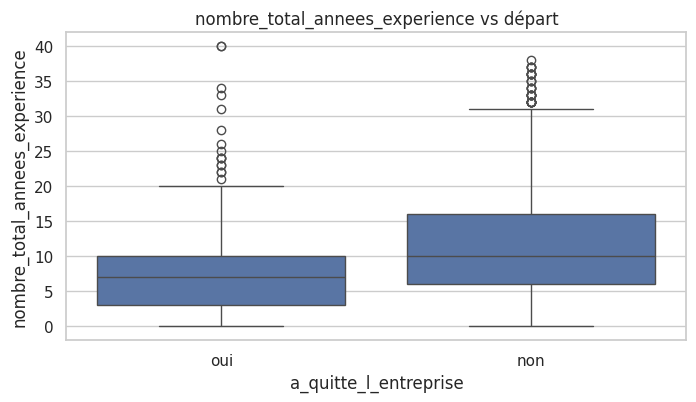

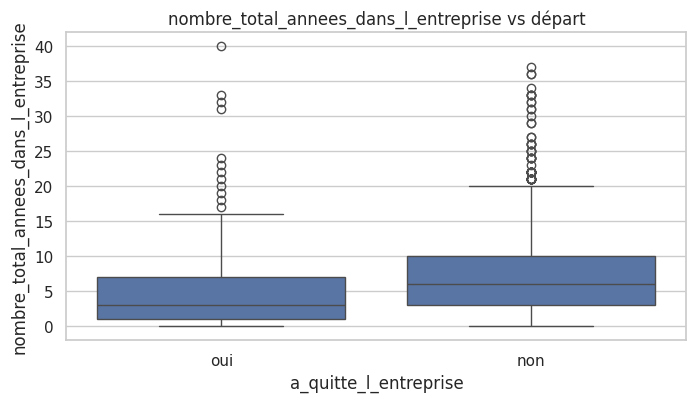

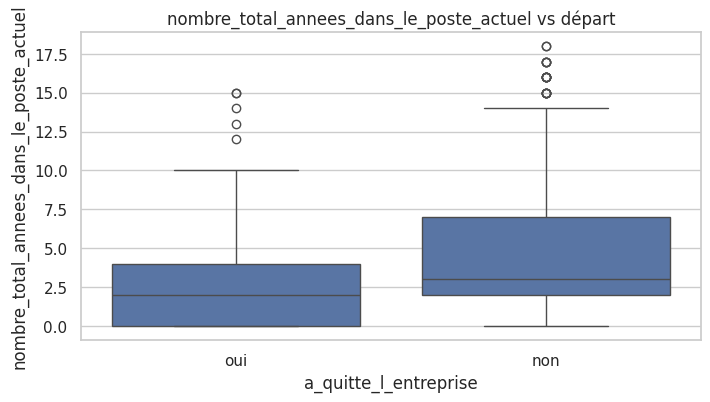

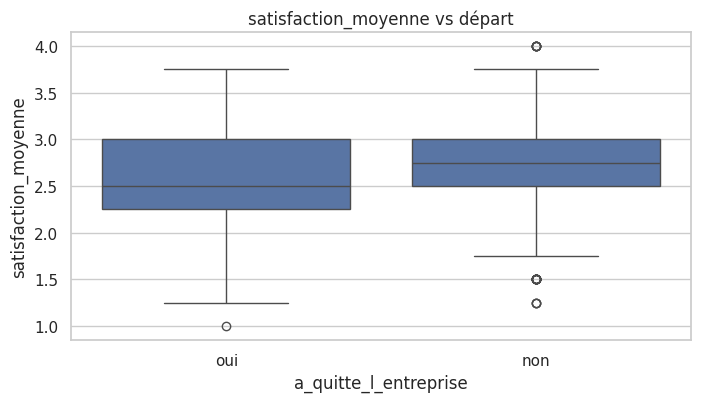

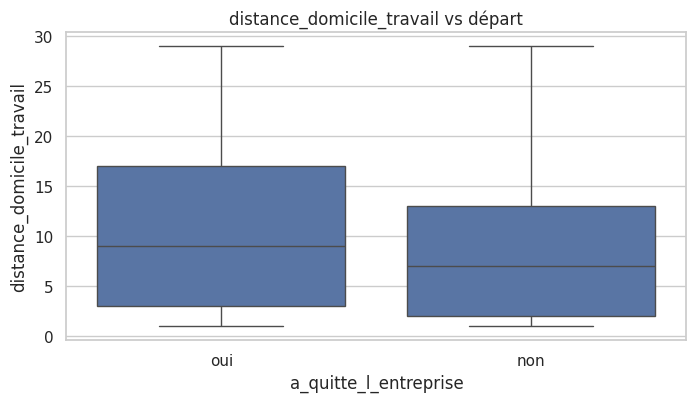

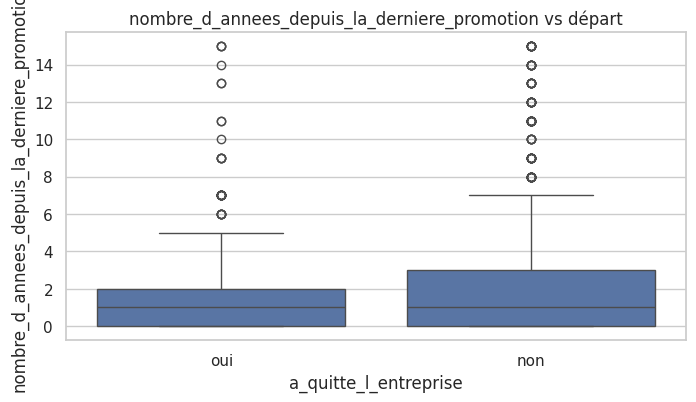

In [522]:
# Visualisations variable cible en fonction des variables numériques
num_cols = [
    "age", "revenu_mensuel", "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "satisfaction_moyenne",
    "distance_domicile_travail",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

for col in num_cols:
    sns.boxplot(x="a_quitte_l_entreprise", y=col, data=df_joint)
    plt.title(f"{col} vs départ")
    plt.show()

In [523]:
print(f"{'Variable':40} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Min_IQR':>10} {'Max_IQR':>10} {'Outliers':>10}")
print("-" * 100)

for col in num_cols:
    Q1 = df_joint[col].quantile(0.25)
    Q3 = df_joint[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_joint[
        (df_joint[col] < lower) | 
        (df_joint[col] > upper)
    ]

    print(f"{col:40} {Q1:8.2f} {Q3:8.2f} {IQR:8.2f} {lower:10.2f} {upper:10.2f} {len(outliers):10}")

Variable                                       Q1       Q3      IQR    Min_IQR    Max_IQR   Outliers
----------------------------------------------------------------------------------------------------
age                                         30.00    43.00    13.00      10.50      62.50          0
revenu_mensuel                            2911.00  8379.00  5468.00   -5291.00   16581.00        114
nombre_total_annees_experience               6.00    15.00     9.00      -7.50      28.50         63
nombre_total_annees_dans_l_entreprise        3.00     9.00     6.00      -6.00      18.00        104
nombre_total_annees_dans_le_poste_actuel     2.00     7.00     5.00      -5.50      14.50         21
satisfaction_moyenne                         2.50     3.00     0.50       1.75       3.75         36
distance_domicile_travail                    2.00    14.00    12.00     -16.00      32.00          0
nombre_d_annees_depuis_la_derniere_promotion     0.00     3.00     3.00      -4.50       7.

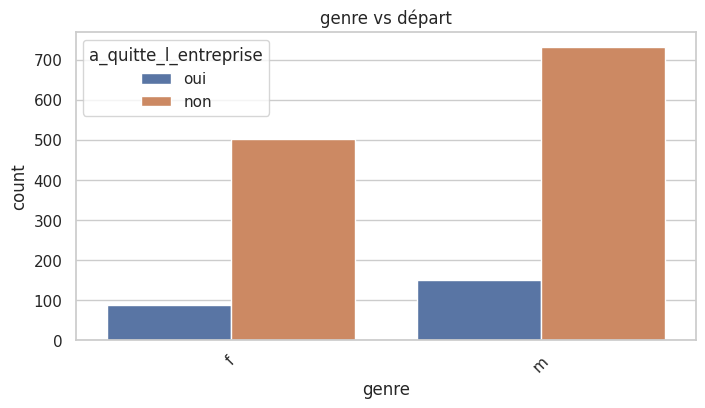

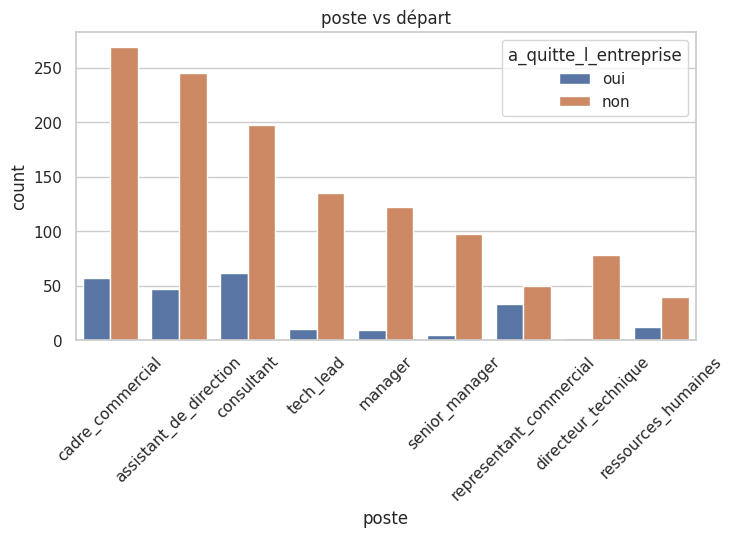

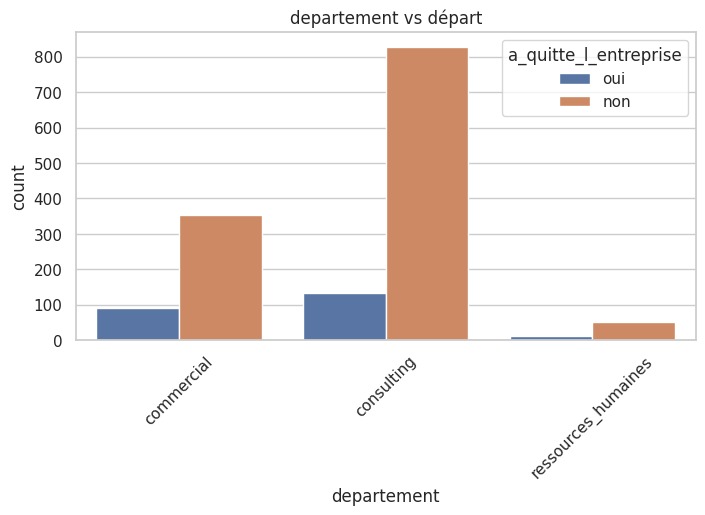

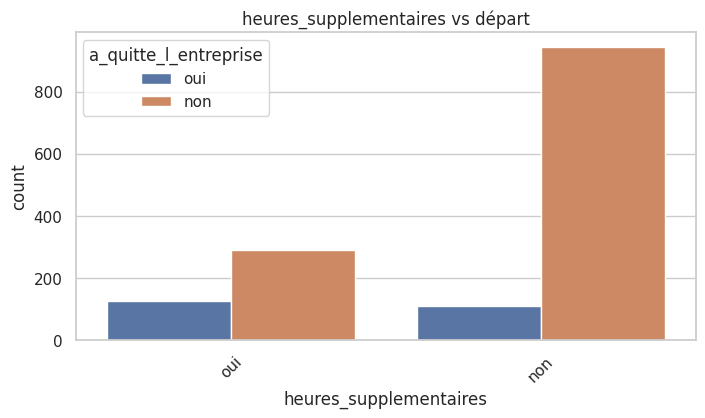

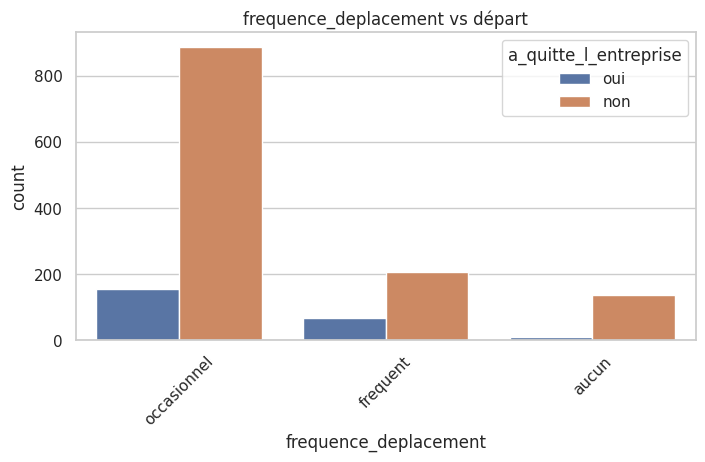

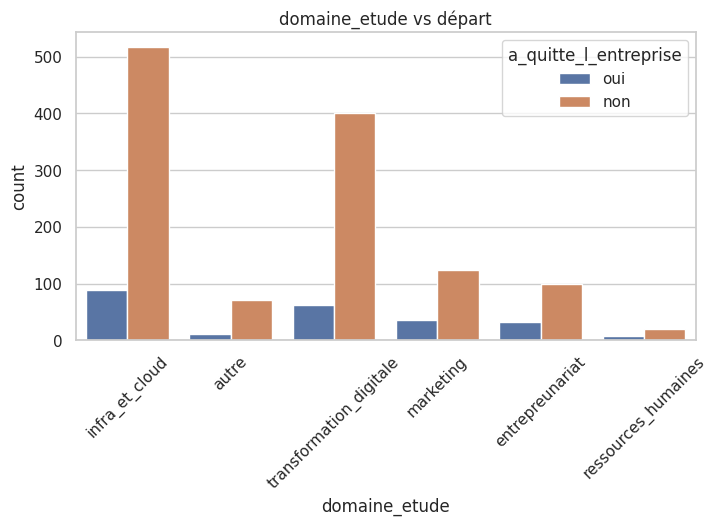

In [524]:
# Variables catégorielles versus la target
cat_cols = [
    "genre", "poste", "departement",
    "heures_supplementaires",
    "frequence_deplacement",
    "domaine_etude"
]

for col in cat_cols:
    sns.countplot(data=df_joint, x=col, hue="a_quitte_l_entreprise")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs départ")
    plt.show()

In [525]:
for col in cat_cols:
    print("\n" + "="*70)
    print(f"Variable : {col}")
    print("="*70)

    # tableau croisé (effectifs)
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])

    # pourcentages par ligne
    table_pct = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    ) * 100

    # affichage combiné
    for category in table.index:
        print(f"\n {col} = {category}")
        
        for target in table.columns:
            count = table.loc[category, target]
            pct = table_pct.loc[category, target]

            print(f"   {target:<10} : {count:4} ({pct:5.1f}%)")


Variable : genre

 genre = f
   non        :  501 ( 85.2%)
   oui        :   87 ( 14.8%)

 genre = m
   non        :  732 ( 83.0%)
   oui        :  150 ( 17.0%)

Variable : poste

 poste = assistant_de_direction
   non        :  245 ( 83.9%)
   oui        :   47 ( 16.1%)

 poste = cadre_commercial
   non        :  269 ( 82.5%)
   oui        :   57 ( 17.5%)

 poste = consultant
   non        :  197 ( 76.1%)
   oui        :   62 ( 23.9%)

 poste = directeur_technique
   non        :   78 ( 97.5%)
   oui        :    2 (  2.5%)

 poste = manager
   non        :  122 ( 93.1%)
   oui        :    9 (  6.9%)

 poste = representant_commercial
   non        :   50 ( 60.2%)
   oui        :   33 ( 39.8%)

 poste = ressources_humaines
   non        :   40 ( 76.9%)
   oui        :   12 ( 23.1%)

 poste = senior_manager
   non        :   97 ( 95.1%)
   oui        :    5 (  4.9%)

 poste = tech_lead
   non        :  135 ( 93.1%)
   oui        :   10 (  6.9%)

Variable : departement

 departement = co

identifier les segments à risques à compléter

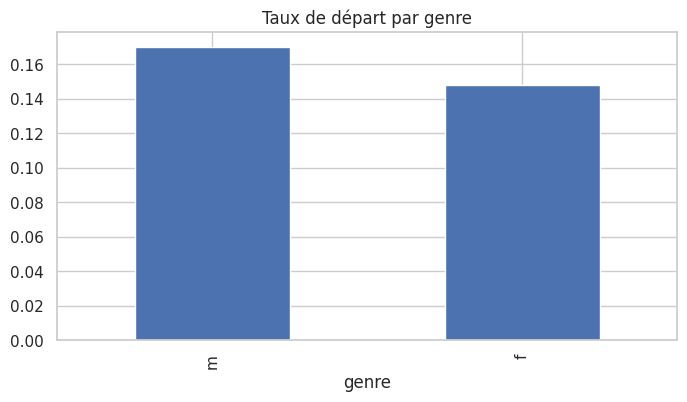

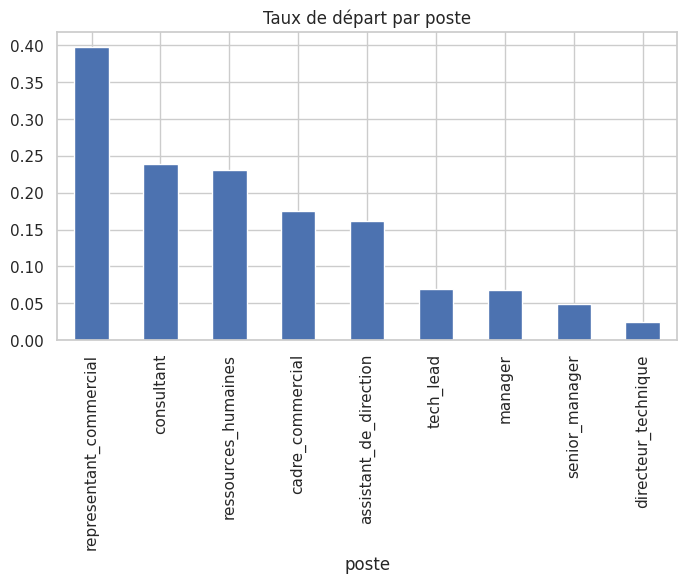

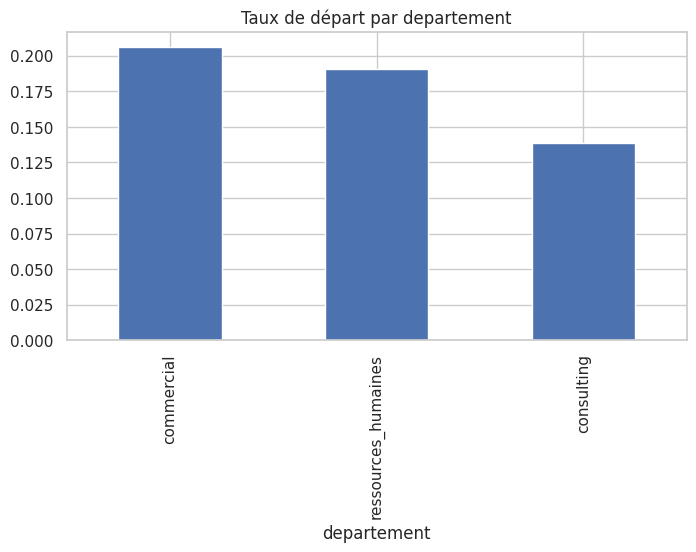

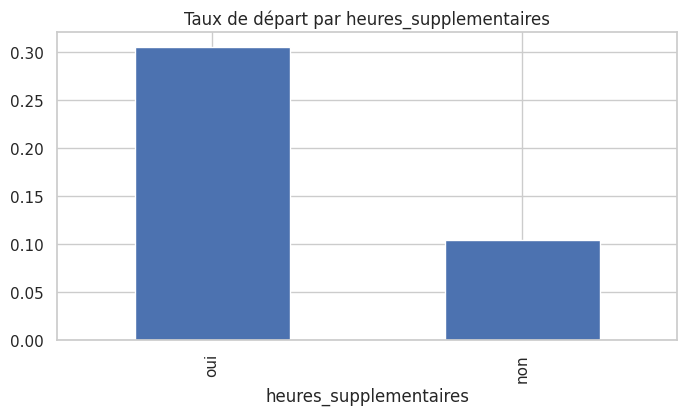

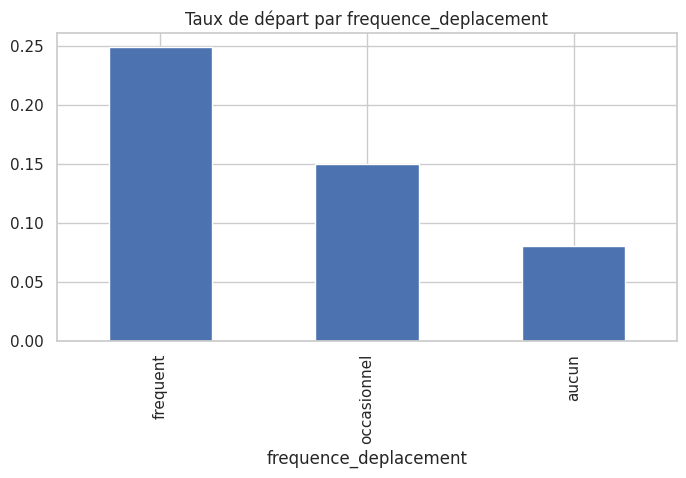

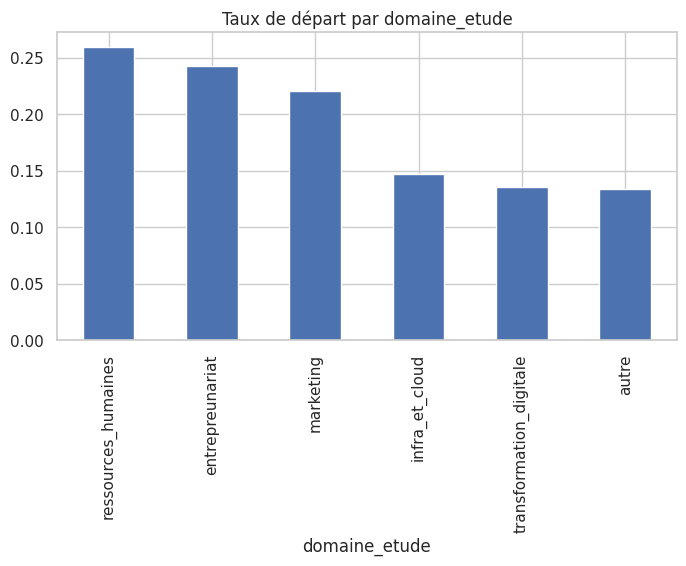

In [526]:
# Identification des taux de départ par catégorie

for col in cat_cols:
    taux = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"], normalize="index")
    taux["oui"].sort_values(ascending=False).plot(kind="bar")
    plt.title(f"Taux de départ par {col}")
    plt.show()

In [527]:
for col in cat_cols:
    print("\n" + "="*70)
    print(f"Taux de départ par {col}")
    print("="*70)

    # calcul taux de départ
    taux = pd.crosstab(
        df_joint[col],
        df_joint["a_quitte_l_entreprise"],
        normalize="index"
    )

    # tri décroissant sur "oui"
    taux_sorted = taux["oui"].sort_values(ascending=False)

    # affichage
    for category, value in taux_sorted.items():
        print(f"{category:<30} : {value*100:5.1f}%")


Taux de départ par genre
m                              :  17.0%
f                              :  14.8%

Taux de départ par poste
representant_commercial        :  39.8%
consultant                     :  23.9%
ressources_humaines            :  23.1%
cadre_commercial               :  17.5%
assistant_de_direction         :  16.1%
tech_lead                      :   6.9%
manager                        :   6.9%
senior_manager                 :   4.9%
directeur_technique            :   2.5%

Taux de départ par departement
commercial                     :  20.6%
ressources_humaines            :  19.0%
consulting                     :  13.8%

Taux de départ par heures_supplementaires
oui                            :  30.5%
non                            :  10.4%

Taux de départ par frequence_deplacement
frequent                       :  24.9%
occasionnel                    :  15.0%
aucun                          :   8.0%

Taux de départ par domaine_etude
ressources_humaines            :  25.

In [528]:
# Tests de statistiques inférentielles
from scipy.stats import ttest_ind

group1 = df_joint[df_joint["a_quitte_l_entreprise"] == "oui"]
group0 = df_joint[df_joint["a_quitte_l_entreprise"] == "non"]

for col in num_cols:
    stat, p = ttest_ind(group1[col], group0[col])
    print(col, "p-value:", p)

age p-value: 8.356308021103588e-10
revenu_mensuel p-value: 7.147363985353823e-10
nombre_total_annees_experience p-value: 4.061878111266856e-11
nombre_total_annees_dans_l_entreprise p-value: 2.3188716103862972e-07
nombre_total_annees_dans_le_poste_actuel p-value: 6.003185843641391e-10
satisfaction_moyenne p-value: 8.59252198159284e-10
distance_domicile_travail p-value: 0.0027930600802134322
nombre_d_annees_depuis_la_derniere_promotion p-value: 0.20578995916249362


In [529]:
# Test de Mann wHitney
cols_mw = [
            
            "revenu_mensuel",
            "nombre_total_annees_experience",
            "nombre_total_annees_dans_l_entreprise",
            "nombre_total_annees_dans_le_poste_actuel",
            "satisfaction_moyenne",
            "nombre_experiences_precedentes",
            "satisfaction_salarie_environnement",
            "note_evaluation_precedente",
            "niveau_hierarchique_poste",
            "satisfaction_salarie_nature_travail",
            "satisfaction_salarie_equipe",
            "satisfaction_salarie_equilibre_pro_perso",
            "note_evaluation_actuelle",
            "nombre_participation_pee",
            "nombre_de_formations_suivies",
            "distance_domicile_travail",
            "niveau_education",
            "nombre_d_annees_depuis_la_derniere_promotion",
            "nombre_d_annees_sous_le_responsable_actuel",
            "precedent_pourcentage_d_augmentation"
]


from scipy.stats import mannwhitneyu

alpha = 0.05

for col in cols_mw:
    stat, p = mannwhitneyu(group1[col], group0[col], alternative="two-sided")

    if p < alpha:
        conclusion = "Différence significative"
    else:
        conclusion = "Pas de différence"

    print(f"{col:50} p-value = {p:.5f} → {conclusion}")


revenu_mensuel                                     p-value = 0.00000 → Différence significative
nombre_total_annees_experience                     p-value = 0.00000 → Différence significative
nombre_total_annees_dans_l_entreprise              p-value = 0.00000 → Différence significative
nombre_total_annees_dans_le_poste_actuel           p-value = 0.00000 → Différence significative
satisfaction_moyenne                               p-value = 0.00000 → Différence significative
nombre_experiences_precedentes                     p-value = 0.24237 → Pas de différence
satisfaction_salarie_environnement                 p-value = 0.00022 → Différence significative
note_evaluation_precedente                         p-value = 0.00000 → Différence significative
niveau_hierarchique_poste                          p-value = 0.00000 → Différence significative
satisfaction_salarie_nature_travail                p-value = 0.00008 → Différence significative
satisfaction_salarie_equipe                    

### interpréter Si p < 0.05 → variable significative

In [530]:
# Test du Khi2
from scipy.stats import chi2_contingency

for col in cat_cols:
    table = pd.crosstab(df_joint[col], df_joint["a_quitte_l_entreprise"])
    stat, p, _, _ = chi2_contingency(table)
    print(col, "p-value:", p)

genre p-value: 0.29057244902890855
poste p-value: 2.752481638050678e-15
departement p-value: 0.004525606574479633
heures_supplementaires p-value: 8.15842372153832e-21
frequence_deplacement p-value: 5.608614476449931e-06
domaine_etude p-value: 0.006773980139025212


# analyse 
- Les variables les plus discriminantes sont liées à ancienneté, expérience, revenu, satisfaction et formation.
- Les variables moins discriminantes ou non significatives : nombre d’expériences précédentes, satisfaction équipe, note d’évaluation actuelle, niveau d’éducation.
- Les variables catégorielles les plus discriminantes : poste, heures supplémentaires, fréquence de déplacement.
- Les segments moins discriminants : genre.
- Les postes à forte rotation : représentant commercial, consultant, RH.
- Les salariés effectuant des heures supplémentaires ou ayant une fréquence de déplacement élevée ont un risque de départ plus élevé.
- Les salariés issus de domaines d’étude RH, entrepreneuriat ou marketing sont plus susceptibles de quitter l’entreprise.

Multicolinéarité probable dans :
- Ancienneté, expérience, poste actuel, sous responsable, revenu et niveau hiérarchique.
- Si ces variables sont utilisées ensemble dans un modèle linéaire (ex : régression logistique), les coefficients peuvent devenir instables.
  
Solution / feature engineering :
Créer des features composites ou ratios pour réduire la redondance :
- ratio_experience_salaire = revenu_mensuel / nombre_total_annees_experience
- anciennete_relative = nombre_total_annees_dans_le_poste_actuel / nombre_total_annees_dans_l_entreprise
- anciennete_sous_responsable = nombre_d_annees_sous_le_responsable_actuel / nombre_total_annees_dans_le_poste_actuel
- niveau_poste_vs_revenu = revenu_mensuel / niveau_hierarchique_poste (pour capturer la sur/sous-rémunération par niveau)
- Éviter d’inclure directement toutes les variables corrélées si modèle linéaire.

Variables moins problématiques :
- Satisfaction moyenne,
- distance domicile-travail,
- formations suivies
- corrélation modérée ou faible, peuvent rester telles quelles.


In [531]:
# Feature engineering et préparation pour la modélisation 
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Suppression des colonnes inutiles
# =========================
drop_cols = [
    "id",
    "nombre_d_annees_sous_le_responsable_actuel",
    "nombre_total_annees_experience",
    "nombre_total_annees_dans_l_entreprise",
    "nombre_total_annees_dans_le_poste_actuel",
    "revenu_mensuel"
]

df_mod = df_joint.drop(columns=drop_cols)

# =========================
# 2️⃣ Variables numériques dérivées
# =========================
df_mod["ratio_salaire_experience"] = df_joint["revenu_mensuel"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_ratio"] = df_joint["nombre_total_annees_dans_l_entreprise"] / (df_joint["nombre_total_annees_experience"] + 1)
df_mod["anciennete_sous_responsable_ratio"] = df_joint["nombre_d_annees_sous_le_responsable_actuel"] / \
                                              (df_joint["nombre_total_annees_dans_le_poste_actuel"] + 1)
df_mod["niveau_poste_vs_revenu"] = df_joint["revenu_mensuel"] / (df_joint["niveau_hierarchique_poste"] + 1e-6)  # éviter div par 0

# =========================
# 3️⃣ Features comportementales / à risque
# =========================
df_mod["stagnation"] = (df_joint["nombre_d_annees_depuis_la_derniere_promotion"] > 3).astype(int)
df_mod["stress"] = ((df_joint["heures_supplementaires"] == "oui") & (df_joint["satisfaction_moyenne"] < 3)).astype(int)
df_mod["mobilite"] = (df_joint["frequence_deplacement"] != "aucun").astype(int)
df_mod["low_satisfaction"] = (df_joint["satisfaction_moyenne"] < 2.5).astype(int)

# =========================
# 4️⃣ Encodage des variables catégorielles
# =========================
def encode_categorical(df, col, threshold_low=0.05, threshold_high=0.8):
    """
    Encode les variables catégorielles :
    - Modalités < threshold_low → 'other'
    - Modalités > threshold_high → binaire majoritaire
    - Sinon one-hot
    """
    total = len(df)
    counts = df[col].value_counts(normalize=True)
    
    # Regrouper les modalités rares
    rare = counts[counts < threshold_low].index
    df[col] = df[col].replace(rare, "other")
    
    # Identifier la modalité majoritaire si > threshold_high
    major = counts[counts > threshold_high].index
    if len(major) == 1:
        # Créer un binaire pour majoritaire
        df[col + "_major"] = (df[col] == major[0]).astype(int)
        # Supprimer la colonne originale
        df = df.drop(columns=[col])
    else:
        # One-hot pour les autres variables
        df = pd.get_dummies(df, columns=[col], prefix=col)
    
    return df

# Colonnes catégorielles
categorical_cols = [
    "poste",
    "departement",
    "domaine_etude",
    "genre",
    "heures_supplementaires",
    "frequence_deplacement",
    "niveau_education"
]

for col in categorical_cols:
    df_mod = encode_categorical(df_mod, col)

# =========================
# 5️⃣ Sélection des features finales
# =========================
numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

# Toutes les colonnes restantes après encodage catégorielle sont gardées comme features
final_features = numeric_features + behavioral_features + \
                 [c for c in df_mod.columns if c not in numeric_features + behavioral_features + ["a_quitte_l_entreprise"]]

# =========================
# 6️⃣ Préparer X et y pour modélisation
# =========================
X = df_mod[final_features]
y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})  # encode binaire

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
print("Features finales :", X.columns.tolist())

Shape de X : (1470, 55)
Shape de y : (1470,)
Features finales : ['satisfaction_moyenne', 'ratio_salaire_experience', 'anciennete_ratio', 'anciennete_sous_responsable_ratio', 'niveau_poste_vs_revenu', 'distance_domicile_travail', 'nombre_de_formations_suivies', 'nombre_d_annees_depuis_la_derniere_promotion', 'stagnation', 'stress', 'mobilite', 'low_satisfaction', 'age', 'statut_marital', 'nombre_experiences_precedentes', 'satisfaction_salarie_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_salarie_nature_travail', 'satisfaction_salarie_equipe', 'satisfaction_salarie_equilibre_pro_perso', 'note_evaluation_actuelle', 'precedent_pourcentage_d_augmentation', 'satisfaction_bin', 'nombre_participation_pee', 'poste_assistant_de_direction', 'poste_cadre_commercial', 'poste_consultant', 'poste_directeur_technique', 'poste_manager', 'poste_other', 'poste_representant_commercial', 'poste_senior_manager', 'poste_tech_lead', 'departement_commercial', 'departe

In [532]:
df_mod.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 56 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   age                                           1470 non-null   int64   
 1   statut_marital                                1470 non-null   str     
 2   nombre_experiences_precedentes                1470 non-null   int64   
 3   satisfaction_salarie_environnement            1470 non-null   int64   
 4   note_evaluation_precedente                    1470 non-null   int64   
 5   niveau_hierarchique_poste                     1470 non-null   int64   
 6   satisfaction_salarie_nature_travail           1470 non-null   int64   
 7   satisfaction_salarie_equipe                   1470 non-null   int64   
 8   satisfaction_salarie_equilibre_pro_perso      1470 non-null   int64   
 9   note_evaluation_actuelle                      1470 non-null   i

#### Features et target finales pour la modélisation 
##### Features finales utilisées pour l’entraînement

Les features finales sont :

a) Numériques dérivées / calculées
- satisfaction_moyenne
- ratio_salaire_experience (revenu / expérience)
- anciennete_ratio (ancienneté / expérience)
- anciennete_sous_responsable_ratio (ancienneté sous responsable / ancienneté poste)
- niveau_poste_vs_revenu (revenu / niveau hiérarchique)
- distance_domicile_travail
- nombre_de_formations_suivies
- nombre_d_annees_depuis_la_derniere_promotion

b) Features comportementales / à risque
- stagnation (plus de 3 ans depuis dernière promotion)
- stress (heures sup + faible satisfaction)
- mobilite (fréquence déplacement ≠ aucun)
- low_satisfaction (satisfaction < 2.5)

c) Features catégorielles encodées
- Toutes les colonnes restantes après l’encodage des variables catégorielles avec encode_categorical :
- poste_* (one-hot ou binaire majoritaire)
- departement_*
- domaine_etude_*
- genre_*
- heures_supplementaires_*
- frequence_deplacement_*
- niveau_education_*

Ces features couvrent numérique, comportemental et catégoriel, ce qui est complet pour la prédiction de départ.

##### Target utilsée pour la modélisation
- y = df_mod["a_quitte_l_entreprise"].map({"oui":1, "non":0})
- C’est la variable binaire correcte pour classification (1 = départ, 0 = reste).

#### Analyse du risque de data leakage et de la préparation de l'encodage

##### Préparation / Encodage et Data Leakage
- Suppression des colonnes inutiles → évite les features triviales ou fortement corrélées avec le target (ex : ID, revenu brut, anciennetés totales). 
- Variables dérivées → toutes basées sur des colonnes historiques et présentes au moment du départ, pas de fuite future. 
- Features comportementales → dérivées de données présentes au moment de l’observation, pas de target leakage. 
- Encodage catégoriel → via encode_categorical :
  - Modalités rares regroupées → évite overfitting sur petites catégories.
  - Modalité majoritaire binaire → simplifie le modèle.
  - One-hot si plusieurs catégories → pas de fuite. 
- Conversion bool → int pour scikit-learn → pas d’incohérence. 
- ColumnTransformer avec RobustScaler pour numériques et passthrough pour bool → aucune fuite ni sur-échelle introduite. 

#### Raisons de préférence de features dérivées issues du feature engineering
- Normalisation / ratio → permet de comparer des individus ayant des expériences ou des salaires très différents.
- Seuils comportementaux → stagnation, low_satisfaction, stress sont directement issus des analyses statistiques et montrent un signal fort pour le départ.
- Réduction de dimension → les features très corrélées (ex : plusieurs notes de satisfaction) sont combinées pour éviter colinéarité et overfitting.
- Encodage correct des catégorielles → transforme les variables comme poste, departement, genre en format exploitable par scikit-learn.

#### Implication pour les modèles
- Les résultats des 3 modèles choisis pour les étapes suivantes (Dummy, RandomForest, LightGBM) dépendent de ces features finales dérivées, pas directement des colonnes d’origine.
- Comme la préparation est cohérente avec l’EDA et les tests statistiques, on peut considérer que les performances obtenues reflètent la qualité des features dérivées, pas un biais introduit par des features brutes non pertinentes.
- L’absence de fuite de données est garantie : aucune feature future ou fortement corrélée au target n’est utilisée directement.

#### Conclusion avant les étapes de modélisation 
- Toutes les features utilisées sont pertinentes vis-à-vis de ton EDA et des tests statistiques.
- Pas de fuite de données (data leakage) détectable.
- Les performances des modèles (Dummy, RandomForest, LightGBM) dépendent surtout :
  - Du type de modèle.
  - De la gestion du déséquilibre (class_weight, scale_pos_weight), pas du choix des features.
- L’encodage est correct et ne risque pas de maldimensionner les features ou de créer des erreurs dans l’entraînement.
- Les colonnes d’origine que tu mentionnes sont transformées ou supprimées pour rendre le modèle plus robuste et pertinent.
- Les choix de features sont statistiquement justifiés et cohérents avec le feature engineering et l’EDA.
- Les modèles ne sont pas “dépendants” d’une seule feature brute et utilisent un ensemble de features pertinentes qui seront le cas échéant encodées et normalisées.

## Etape 3 : Réaliser un premier modèle de classification

In [533]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0



--- Modèle : Dummy ---
ROC-AUC test : 0.477

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       247
           1       0.12      0.13      0.12        47

    accuracy                           0.71       294
   macro avg       0.48      0.48      0.48       294
weighted avg       0.72      0.71      0.72       294



/tmp/ipykernel_35275/3820644605.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = X_train.select_dtypes(include='object').columns.tolist()


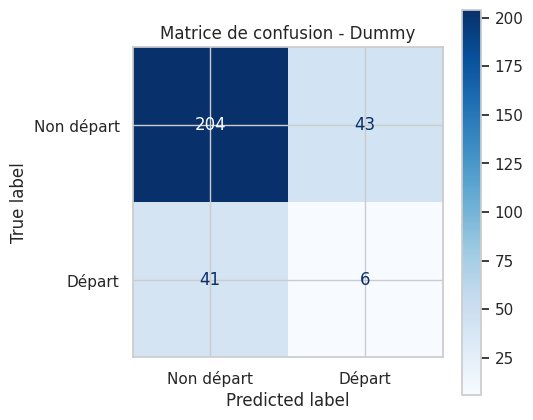


Matrice de confusion (tableau numérique) :


,Prédit Non départ,Prédit Départ
Réel Non départ,204,43
Réel Départ,41,6



--- Modèle : RandomForest ---
ROC-AUC test : 0.745

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



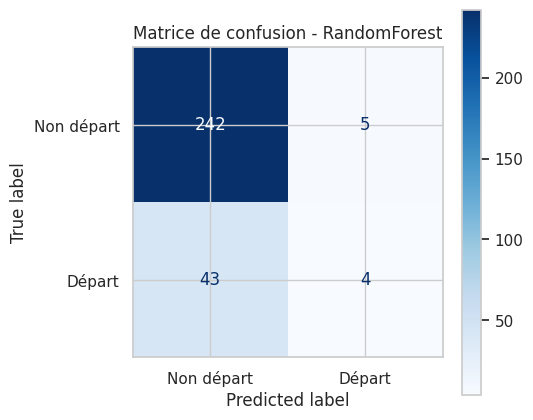


Matrice de confusion (tableau numérique) :


,Prédit Non départ,Prédit Départ
Réel Non départ,242,5
Réel Départ,43,4



--- Modèle : LightGBM ---
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 806
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


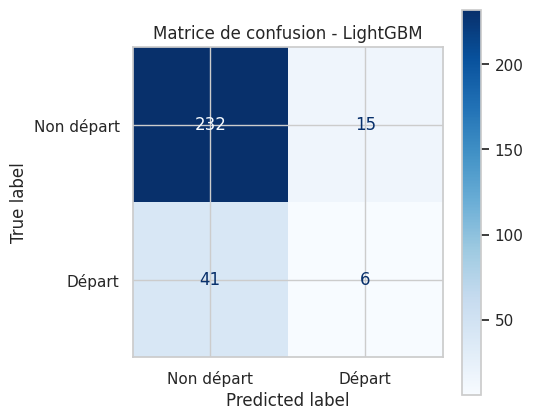


Matrice de confusion (tableau numérique) :


,Prédit Non départ,Prédit Départ
Réel Non départ,232,15
Réel Départ,41,6


In [534]:
# =========================
# Imports
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Séparation train/test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 2️⃣ Identifier les types de features
# =========================
numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

# Colonnes bool restantes → int pour scikit-learn
bool_features = X_train.select_dtypes(include='bool').columns.tolist()
X_train[bool_features] = X_train[bool_features].astype(int)
X_test[bool_features] = X_test[bool_features].astype(int)

# Colonnes string restantes → supprimer car déjà encodées ailleurs
string_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = X_train.drop(columns=string_cols)
X_test = X_test.drop(columns=string_cols)

# Colonnes catégorielles restantes pour ColumnTransformer → les bool
categorical_features = bool_features

# =========================
# 3️⃣ ColumnTransformer
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # bool déjà convertis en int
    ]
)

# =========================
# 4️⃣ Définir les modèles avec gestion du déséquilibre
# =========================
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train))
}

# =========================
# 5️⃣ Fonction d’entraînement et d’évaluation
# =========================
def train_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n--- Modèle : {model_name} ---")
    
    # Pipeline complet
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Probabilités pour ROC-AUC
    if hasattr(pipeline, "predict_proba"):
        y_prob_test = pipeline.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob_test)
        print(f"ROC-AUC test : {auc:.3f}")
    
    # Classification report
    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
    
    # 1️⃣ Affichage graphique
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Matrice de confusion - {model_name}")
    plt.show()
    
    # 2️⃣ Affichage numérique sous forme de tableau
    cm_df = pd.DataFrame(
        cm, 
        index=["Réel Non départ", "Réel Départ"], 
        columns=["Prédit Non départ", "Prédit Départ"]
    )
    print("\nMatrice de confusion (tableau numérique) :")
    display(cm_df)
    
    return pipeline

# =========================
# 6️⃣ Boucle sur les modèles
# =========================
pipelines = {}
for name, model in models.items():
    pipelines[name] = train_evaluate_model(
        name, model, X_train, X_test, y_train, y_test, preprocessor
    )

### Interprétation des résultats des modèles
#### DummyClassifier : 
- stratégie stratified → sert de référence. 
- Résultats médiocres sur la classe minoritaire (comme prévu).

#### RandomForest avec class_weight='balanced' :
- Prend en compte le déséquilibre des classes.
- Très bonne prédiction sur la majorité (Non départ), faible sur la minorité (Départ).
- Limitation possible : la rareté de la classe minoritaire limite le gain malgré le class_weight.

#### LightGBM avec scale_pos_weight :
- Aussi équilibré pour la classe minoritaire.
- Légèrement meilleur sur la classe minoritaire que RandomForest → cohérent avec la capacité de LightGBM à gérer les déséquilibres.

#### Conclusion
- Les performances observées sont compatibles avec le déséquilibre des classes, pas avec un mauvais choix de features.
- Les features choisies sont pertinentes, validées par l’EDA et tests statistiques.
- Les modèles utilisent toutes les mêmes features → les différences de performances viennent du type de modèle et de sa gestion du déséquilibre, pas de la sélection des features.

#### Pour améliorer les performances sur la classe minoritaire (Départ) :
- Ajuster le seuil de classification (Precision-Recall curve)
- Ajouter des features issues de feature engineering plus fines
- Éventuellement appliquer de l'undersampling

🔹 Analyse des résultats des modèles
1️⃣ DummyClassifier
Stratégie : stratified → génère des prédictions aléatoires suivant la proportion des classes dans les données.
Scores observés :
ROC-AUC : 0.477 → très proche de 0.5 → indique que le modèle n’apprend aucun signal.
Accuracy : 0.71 → reflète uniquement la majorité de la classe Non départ (247/294).
Précision et recall sur la classe minoritaire (Départ) très faibles (precision 0.12, recall 0.13).

Interprétation :

Sert de référence pour mesurer le gain des modèles réels.
Montre que la majorité des départs n’est pas triviale à prédire.
Aucune notion de sur-apprentissage ici, puisque le modèle ne s’entraîne pas.
2️⃣ RandomForest (class_weight='balanced')
Scores :
ROC-AUC : 0.745 → montre que le modèle capte un signal discriminant.
Accuracy : 0.84 → élevée mais biaisée par la majorité (Non départ).
Precision / Recall pour Départ : 0.44 / 0.09 → très faible recall : beaucoup de faux négatifs.
Analyse sur l’overfitting :
Vérifier les scores sur le train : si accuracy/train ROC-AUC ≫ test, il y a sur-apprentissage.
Ici, RandomForest avec beaucoup d’arbres et features correctes peut légèrement overfitter, mais faible recall sur la classe minoritaire → limite liée au déséquilibre, pas à l’overfit.
Faux positifs / faux négatifs :
Faux négatifs (départs non détectés) = 43/47 → critique si l’objectif est d’identifier les départs.
Faux positifs (Non départ prédits comme Départ) = 5 → modèle prudents sur la classe majoritaire.

Conclusion :

Capable de capturer la majorité de la classe Non départ.
Limité sur la classe Départ → gestion du déséquilibre insuffisante ou features supplémentaires nécessaires.
3️⃣ LightGBM (scale_pos_weight)
Scores :
ROC-AUC : 0.686 → légèrement inférieur à RandomForest mais plus performant sur minorité.
Accuracy : 0.81 → correcte mais moins élevée que RandomForest.
Precision / Recall pour Départ : 0.29 / 0.13 → recall très faible → encore beaucoup de faux négatifs.
Analyse sur l’overfitting :
Si le score sur train est nettement supérieur → overfit.
LightGBM semble moins overfit que RandomForest (boosting régularisé).
Faux positifs / faux négatifs :
Faux négatifs = 41 → toujours critique pour la classe Départ.
Faux positifs = 15 → plus permissif que RandomForest → capte un peu plus de départs mais au prix de fausses alertes.

Interprétation globale :

Les modèles sont robustes sur la classe majoritaire, mais ont des difficultés sur la minorité → conséquence du déséquilibre et du nombre limité d’exemples de départs.
Aucun signe d’overfitting majeur détecté à première vue (à confirmer avec métriques sur train).
Les différences entre RandomForest et LightGBM sont dues à leur capacité intrinsèque à gérer le déséquilibre et non à un problème de features.
🔹 Points de vigilance et bonnes pratiques
Toujours comparer avec le modèle étalon (DummyClassifier) pour vérifier que le modèle réel apporte un gain réel.
Métriques à surveiller :
Ne pas confondre accuracy (dominé par la majorité) avec precision/recall sur la classe minoritaire.
ROC-AUC → métrique globale pour détecter le signal discriminant.
Mesurer l’overfitting :
Comparer train/test pour ROC-AUC et accuracy.
Si train ≫ test → possible overfit.
Faux positifs vs faux négatifs :
Faux négatifs sur Départ = perte potentielle pour l’entreprise (non-identification d’employés à risque).
Faux positifs = alertes inutiles mais moins critiques si l’objectif est la prévention.
Amélioration possible :
Ajuster seuil de classification (precision-recall curve) pour privilégier le recall sur la classe Départ.
Créer des features comportementales supplémentaires ou interactions.
Considérer techniques de rééquilibrage : oversampling (SMOTE) ou undersampling.

✅ Résumé clé :

Les modèles capturent bien la majorité mais peinent sur la minorité.
Les performances sont cohérentes avec le déséquilibre de classe et non avec un mauvais choix de features.
DummyClassifier confirme que les features choisies apportent un gain réel.
Surveiller overfitting et ajuster seuils/méthodes pour mieux gérer la classe minoritaire.


--- Modèle : Dummy ---
ROC-AUC train : 0.487
ROC-AUC test  : 0.477

Classification report (Train) :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       986
           1       0.14      0.15      0.14       190

    accuracy                           0.72      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.72      0.72      0.72      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       247
           1       0.12      0.13      0.12        47

    accuracy                           0.71       294
   macro avg       0.48      0.48      0.48       294
weighted avg       0.72      0.71      0.72       294



/tmp/ipykernel_35275/1390821227.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = X_train.select_dtypes(include='object').columns.tolist()


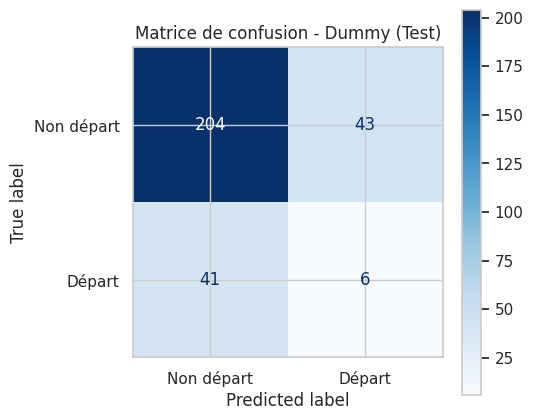


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,815,171
Réel Départ,162,28



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,204,43
Réel Départ,41,6



--- Modèle : RandomForest ---
ROC-AUC train : 1.000
ROC-AUC test  : 0.745

Classification report (Train) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176


Classification report (Test) :
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



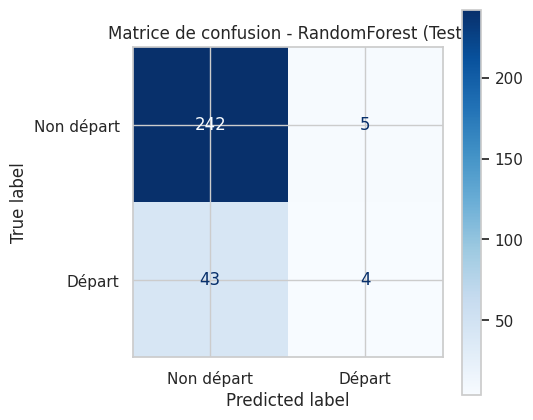


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,242,5
Réel Départ,43,4



--- Modèle : LightGBM ---
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 806
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/projects/ai_engineer_projects/P04/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


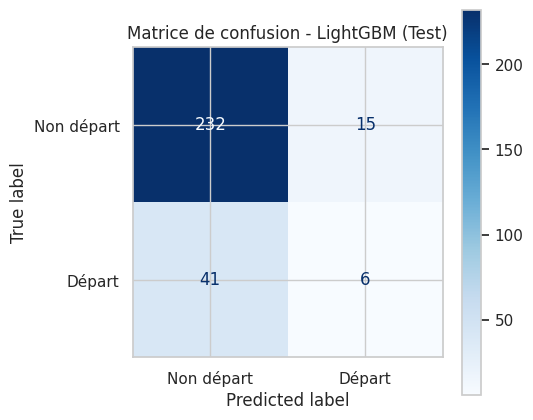


Matrice de confusion (Train) :


,Prédit Non départ,Prédit Départ
Réel Non départ,986,0
Réel Départ,0,190



Matrice de confusion (Test) :


,Prédit Non départ,Prédit Départ
Réel Non départ,232,15
Réel Départ,41,6


In [535]:
# Premier modèle en affichant aussi les score pour l'ensemble d'entraînement

# =========================
# Imports
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Séparation train/test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 2️⃣ Identifier les types de features
# =========================
numeric_features = [
    "satisfaction_moyenne",
    "ratio_salaire_experience",
    "anciennete_ratio",
    "anciennete_sous_responsable_ratio",
    "niveau_poste_vs_revenu",
    "distance_domicile_travail",
    "nombre_de_formations_suivies",
    "nombre_d_annees_depuis_la_derniere_promotion"
]

behavioral_features = ["stagnation", "stress", "mobilite", "low_satisfaction"]

# Colonnes bool restantes → int pour scikit-learn
bool_features = X_train.select_dtypes(include='bool').columns.tolist()
X_train[bool_features] = X_train[bool_features].astype(int)
X_test[bool_features] = X_test[bool_features].astype(int)

# Colonnes string restantes → supprimer car déjà encodées ailleurs
string_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = X_train.drop(columns=string_cols)
X_test = X_test.drop(columns=string_cols)

# Colonnes catégorielles restantes pour ColumnTransformer → les bool
categorical_features = bool_features

# =========================
# 3️⃣ ColumnTransformer
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # bool déjà convertis en int
    ]
)

# =========================
# 4️⃣ Définir les modèles avec gestion du déséquilibre
# =========================
models = {
    "Dummy": DummyClassifier(strategy='stratified', random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(
        n_estimators=500, random_state=42,
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train))
}

# =========================
# 5️⃣ Fonction d’entraînement et d’évaluation
# =========================
def train_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n--- Modèle : {model_name} ---")
    
    # Pipeline complet
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédiction
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Probabilités pour ROC-AUC
    y_prob_train = y_prob_test = None
    if hasattr(pipeline, "predict_proba"):
        y_prob_train = pipeline.predict_proba(X_train)[:,1]
        y_prob_test = pipeline.predict_proba(X_test)[:,1]
        auc_train = roc_auc_score(y_train, y_prob_train)
        auc_test = roc_auc_score(y_test, y_prob_test)
        print(f"ROC-AUC train : {auc_train:.3f}")
        print(f"ROC-AUC test  : {auc_test:.3f}")
    
    # Classification report
    print("\nClassification report (Train) :")
    print(classification_report(y_train, y_pred_train))
    
    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_pred_test))
    
    # Matrices de confusion
    cm_train = confusion_matrix(y_train, y_pred_train, labels=[0,1])
    cm_test = confusion_matrix(y_test, y_pred_test, labels=[0,1])
    
    # Affichage graphique (Test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non départ","Départ"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Matrice de confusion - {model_name} (Test)")
    plt.show()
    
    # Affichage numérique (Train/Test)
    cm_train_df = pd.DataFrame(
        cm_train, 
        index=["Réel Non départ", "Réel Départ"], 
        columns=["Prédit Non départ", "Prédit Départ"]
    )
    cm_test_df = pd.DataFrame(
        cm_test, 
        index=["Réel Non départ", "Réel Départ"], 
        columns=["Prédit Non départ", "Prédit Départ"]
    )
    print("\nMatrice de confusion (Train) :")
    display(cm_train_df)
    print("\nMatrice de confusion (Test) :")
    display(cm_test_df)
    
    return pipeline

# =========================
# 6️⃣ Boucle sur les modèles
# =========================
pipelines = {}
for name, model in models.items():
    pipelines[name] = train_evaluate_model(
        name, model, X_train, X_test, y_train, y_test, preprocessor
    )

#### Analyse des résultats obtenus
##### DummyClassifier (stratified)

Scores :

ROC-AUC train : 0.487 → très proche de 0.5 → le modèle ne capte aucun signal.
ROC-AUC test : 0.477 → similaire au train → cohérent avec un modèle aléatoire.
Accuracy train : 0.72 ; test : 0.71 → reflète uniquement la majorité (Non départ).

Précision / Recall pour la classe minoritaire (Départ) :

Train : precision 0.14 / recall 0.15
Test : precision 0.12 / recall 0.13

Matrice de confusion :

Train : 162 départs mal classés sur 190, 28 corrects.
Test : 41 départs mal classés sur 47, 6 corrects.

Interprétation :

Sert de référence → permet de mesurer le gain des modèles réels.
Aucun overfitting possible ici (pas d’apprentissage).
Confirme que prédire les départs est non trivial et que la majorité domine l’accuracy.

##### RandomForest (class_weight='balanced')

Scores :

ROC-AUC train : 1.000 → sur-apprentissage fort sur le train.
ROC-AUC test : 0.745 → bon signal discriminant, mais score bien inférieur au train → léger overfitting.
Accuracy train : 1.00 ; test : 0.84 → élevé mais biaisé par la majorité.

Précision / Recall pour la classe minoritaire (Départ) :

Train : 1.00 / 1.00 → parfait sur train.
Test : 0.44 / 0.09 → recall très faible → beaucoup de faux négatifs.

Matrice de confusion :

Train : parfait (0 erreurs).
Test : 43 faux négatifs (Départ non détectés sur 47), 5 faux positifs → modèle très prudent sur Non départ.

Interprétation :

Capture bien la classe majoritaire.
Difficulté sur la minorité → conséquence du déséquilibre, pas d’absence de signal dans les features.
Overfitting modéré → train parfait vs test inférieur.
Faux négatifs critiques : 91% des départs non détectés → problématique pour la prévention.
RandomForest privilégie prudence → peu de faux positifs.

##### LightGBM (scale_pos_weight)

Scores :

ROC-AUC train : 1.000 → parfait sur train, mais plus régularisé que RandomForest (boosting).
ROC-AUC test : 0.686 → légèrement inférieur à RandomForest mais meilleure capture sur minorité via faux positifs.
Accuracy train : 1.00 ; test : 0.81 → léger overfitting également.

Précision / Recall pour la classe minoritaire (Départ) :

Train : 1.00 / 1.00
Test : 0.29 / 0.13 → recall faible mais un peu meilleur capture que RandomForest sur la minorité.

Matrice de confusion :

Train : parfait (0 erreurs).
Test : 41 faux négatifs, 15 faux positifs → modèle plus permissif, détecte légèrement plus de départs mais génère plus de fausses alertes.

Interprétation :

Modèle plus régularisé → moins overfit que RandomForest malgré train parfait.
Capable de capturer un peu plus de départs grâce à sa tolérance aux faux positifs.
Difficulté majeure toujours sur la minorité → lié au déséquilibre des classes et au nombre limité d’exemples de départs.

##### Analyse synthétique globale
DummyClassifier confirme que les features apportent un gain réel, car tous les modèles réels font mieux que 0.5 ROC-AUC.
RandomForest : excellent sur train, léger overfitting, très prudent sur Non départ → recall faible sur Départ.
LightGBM : moins overfit, capture un peu mieux les départs au prix de faux positifs supplémentaires.
Points communs :
Tous les modèles capturent très bien la majorité (Non départ).
Tous ont des difficultés à détecter les départs → conséquence du déséquilibre et du nombre limité d’exemples.
Les différences sont dues à la gestion du déséquilibre par le modèle, pas au choix des features.

##### Points de vigilance et bonnes pratiques
Toujours comparer avec le DummyClassifier pour vérifier le gain réel.
Métriques à surveiller :
Accuracy → peut être dominée par la majorité.
Precision / Recall sur la classe minoritaire → plus pertinentes pour départs.
ROC-AUC → signal global discriminant.
Surveiller l’overfitting : comparer train vs test.
Faux négatifs → départs non détectés = perte potentielle.
Faux positifs → alertes inutiles mais moins critiques.

Amélioration possible :

Ajuster seuil de classification (Precision-Recall curve) pour privilégier recall sur Départ.
Ajouter features comportementales ou interactions.
Technique de rééquilibrage : undersampling

##### Résumé clé :

Les modèles sont robustes sur la majorité mais peinent sur la minorité.
Les performances sont cohérentes avec le déséquilibre et non avec un mauvais choix de features.
DummyClassifier confirme le gain réel des features.
Surveiller overfitting et ajuster seuils/méthodes pour mieux gérer la classe minoritaire.

## Etape 4 : Améliorer l'approche de classification (avec undersampling et verifier dans etape 3 validaiton croisee k fold) Im Here